## Bootstrap
Run the next cell once at the start of each kernel/runtime.

In [3]:
# ============================================================
# BOOTSTRAP: local + Colab CPU
#
# Local: d?ng tr?c ti?p source v? .env trong working tree.
# Colab browser: l?y config t? Colab Secrets.
# VS Code ? Colab CPU: d?n m?t COLAB_RUNTIME_CONFIG_B64 bundle duy nh?t.
# ============================================================
from __future__ import annotations

import base64
import binascii
import json
import os
import subprocess
import sys
from getpass import getpass
from pathlib import Path

from dotenv import load_dotenv

REPO_OWNER = "lbngyn"
REPO_NAME = "Santander-Product-Recommendation"
REPO_BRANCH = "feat/colab-local-run"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
RUNTIME_CONFIG_KEYS = (
    "GITHUB_TOKEN",
    "GCP_SERVICE_ACCOUNT_JSON",
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET",
    "GCS_RAW_PREFIX",
    "GCS_CHECKPOINT_PREFIX",
)


def is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and requirements.txt.")


def run_git(arguments: list[str], token: str) -> None:
    credentials = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    command = ["git", "-c", f"http.https://github.com/.extraheader=AUTHORIZATION: basic {credentials}", *arguments]
    subprocess.run(command, check=True)


def decode_runtime_bundle(encoded_value: str) -> dict[str, str]:
    try:
        payload = base64.b64decode(encoded_value, validate=True).decode("utf-8")
        config = json.loads(payload)
    except (binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as error:
        raise ValueError("COLAB_RUNTIME_CONFIG_B64 must be a Base64-encoded JSON object.") from error
    missing = [key for key in RUNTIME_CONFIG_KEYS if not config.get(key)]
    if missing:
        raise ValueError(f"Runtime config bundle is missing: {', '.join(missing)}")
    if isinstance(config["GCP_SERVICE_ACCOUNT_JSON"], dict):
        config["GCP_SERVICE_ACCOUNT_JSON"] = json.dumps(config["GCP_SERVICE_ACCOUNT_JSON"])
    return {key: str(config[key]) for key in RUNTIME_CONFIG_KEYS}


def load_colab_ui_secrets() -> dict[str, str] | None:
    """Return secrets only when this kernel runs through the Colab browser UI."""
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
        if not github_token:
            return None
        config = {"GITHUB_TOKEN": github_token}
        for key in RUNTIME_CONFIG_KEYS[1:]:
            value = userdata.get(key)
            if not value:
                raise RuntimeError(f"Missing Colab Secret: {key}")
            config[key] = value
        return config
    except Exception:
        return None


def load_colab_runtime_config() -> dict[str, str]:
    """Use browser Secrets, env bundle, or one secure runtime prompt."""
    ui_config = load_colab_ui_secrets()
    if ui_config:
        print("Using Colab Secrets.")
        return ui_config

    encoded_value = os.getenv("COLAB_RUNTIME_CONFIG_B64")
    if not encoded_value:
        encoded_value = getpass("Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ")
    return decode_runtime_bundle(encoded_value)


IS_COLAB = is_colab_runtime()
ENV = "colab" if IS_COLAB else "local"
os.environ["SANTANDER_RUNTIME"] = ENV

if IS_COLAB:
    runtime_config = load_colab_runtime_config()
    os.environ.update(runtime_config)
    github_token = runtime_config["GITHUB_TOKEN"]
    PROJECT_ROOT = Path("/content") / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning source to Colab fast disk...")
        run_git(["clone", "--branch", REPO_BRANCH, "--single-branch", REPO_URL, str(PROJECT_ROOT)], github_token)
    else:
        print("Syncing latest source to Colab fast disk...")
        run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
        run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
        run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    if not requirements_path.is_file():
        raise FileNotFoundError(f"requirements.txt is missing from branch {REPO_BRANCH}.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)], check=True)

    # Persist raw CSV and Parquet checkpoints between Colab runtimes.
    from google.colab import drive
    drive_mount = Path("/content/drive")
    if not (drive_mount / "MyDrive").exists():
        drive.mount(str(drive_mount))
    DATA_ROOT = drive_mount / "MyDrive/projects/santander/data"
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    load_dotenv(PROJECT_ROOT / ".env")
    DATA_ROOT = Path(os.getenv("SANTANDER_DATA_ROOT", PROJECT_ROOT / "data"))

os.environ["SANTANDER_DATA_ROOT"] = str(DATA_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready | environment={ENV} | source={PROJECT_ROOT}")


Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ··········
Cloning source to Colab fast disk...
Mounted at /content/drive
Notebook ready | environment=colab | source=/content/Santander-Product-Recommendation


In [4]:
# COLAB SOURCE UPDATE
# 1) Tr?n local: git add/commit/push source m?i l?n REPO_BRANCH.
# 2) Tr?n Colab: ch?y cell n?y, sau ?? ch?y l?i c?c cell import/EDA c?n d?ng code m?i.

if not IS_COLAB:
    print("Local environment: source is already current; no Colab sync is needed.")
else:
    status = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "status", "--porcelain"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if status:
        raise RuntimeError(
            "The Colab source copy has uncommitted changes. Do not overwrite it; "
            "restart the runtime or resolve those changes first."
        )

    run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
        check=True,
    )

    import importlib
    importlib.invalidate_caches()
    stale_modules = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    for name in stale_modules:
        del sys.modules[name]
    print(f"Colab source updated from {REPO_BRANCH}; cleared {len(stale_modules)} cached src modules. Re-run the import/config cell, then the desired EDA cells.")


Colab source updated from feat/colab-local-run; cleared 0 cached src modules. Re-run the import/config cell, then the desired EDA cells.


# Start Ingest

In [23]:
from src.data.ingest import config_from_environment, run_default_ingests

INGEST_CONFIG = config_from_environment()


In [24]:
ingest_results = run_default_ingests(
    config=INGEST_CONFIG,
    # force_rebuild=True,
)
ingest_results

[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/train_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/train.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.
[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/test_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/test.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.


{'train_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/train.parquet',
  'checkpoint_uri': None},
 'test_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/test.parquet',
  'checkpoint_uri': None}}

# EDA

## EDA setup
Create a disk-backed DuckDB connection and reusable helpers. Queries scan Parquet directly; only aggregates and bounded samples are returned to pandas.

In [25]:
from __future__ import annotations

import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Vị trí data mà duckdb sẽ dùng để đọc các file tạm thời
TRAIN_PARQUET = INGEST_CONFIG.checkpoint_dir / 'train.parquet'
TEST_PARQUET = INGEST_CONFIG.checkpoint_dir / 'test.parquet'
if not TRAIN_PARQUET.is_file():
    raise FileNotFoundError(f'Missing checkpoint: {TRAIN_PARQUET}. Run ingestion first.')

# Nơi duckdb lưu trữ các file tạm thời, có thể override bằng biến môi trường DUCKDB_TEMP_DIRECTORY
DUCKDB_TEMP_DIR = Path(os.getenv('DUCKDB_TEMP_DIRECTORY', Path(os.getenv('SANTANDER_WORK_ROOT', 'data')) / 'duckdb_temp'))
DUCKDB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(database=':memory:')
con.execute(f"SET temp_directory = '{str(DUCKDB_TEMP_DIR).replace(chr(39), chr(39) * 2)}'")
con.execute("SET memory_limit = '2GB'" if ENV == 'local' else "SET memory_limit = '8GB'")

def q(sql: str, *params: object) -> pd.DataFrame:
    """Run an out-of-core DuckDB query and materialize only its result."""
    return con.execute(sql, list(params)).df()

def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'

def scan(path: Path) -> str:
    return 'read_parquet(?)'

TRAIN_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TRAIN_PARQUET))
TEST_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TEST_PARQUET)) if TEST_PARQUET.is_file() else None
ALL_COLUMNS = TRAIN_COLUMNS['column_name'].tolist()
PRODUCT_COLUMNS = [column for column in ALL_COLUMNS if column.endswith('_ult1')]
DATE_COLUMNS = [column for column in ALL_COLUMNS if column.startswith('fecha_') or column == 'ult_fec_cli_1t']
# NUMERIC_COLUMNS = [column for column in ['ncodpers', 'age', 'antiguedad', 'renta'] if column in ALL_COLUMNS]
# CATEGORICAL_COLUMNS = [column for column in ALL_COLUMNS if column not in set(NUMERIC_COLUMNS + DATE_COLUMNS + PRODUCT_COLUMNS)]
EDA_SAMPLE_ROWS = 10
EDA_TOP_N = 15
EDA_PLOT_SAMPLE_ROWS = 200_000


In [26]:
PRODUCT_CATALOG = {
    "ind_ahor_fin_ult1": "Tài khoản tiết kiệm", "ind_aval_fin_ult1": "Bảo lãnh tài chính",
    "ind_cco_fin_ult1": "Tài khoản thanh toán", "ind_cder_fin_ult1": "Tài khoản phái sinh",
    "ind_cno_fin_ult1": "Tài khoản trả lương", "ind_ctju_fin_ult1": "Tài khoản trẻ em",
    "ind_ctma_fin_ult1": "Tài khoản Más Particular", "ind_ctop_fin_ult1": "Tài khoản cá nhân",
    "ind_ctpp_fin_ult1": "Tài khoản cá nhân Plus", "ind_deco_fin_ult1": "Tiền gửi ngắn hạn",
    "ind_deme_fin_ult1": "Tiền gửi trung hạn", "ind_dela_fin_ult1": "Tiền gửi dài hạn",
    "ind_ecue_fin_ult1": "Tài khoản điện tử (e-Account)", "ind_fond_fin_ult1": "Quỹ đầu tư",
    "ind_hip_fin_ult1": "Vay thế chấp / Bất động sản", "ind_plan_fin_ult1": "Kế hoạch hưu trí",
    "ind_pres_fin_ult1": "Vay tiêu dùng", "ind_reca_fin_ult1": "Thanh toán thuế",
    "ind_tjcr_fin_ult1": "Thẻ tín dụng", "ind_valo_fin_ult1": "Chứng khoán",
    "ind_viv_fin_ult1": "Tài khoản mua nhà", "ind_nomina_ult1": "Thu nhập từ lương",
    "ind_nom_pens_ult1": "Thu nhập hưu trí", "ind_recibo_ult1": "Trích nợ tự động"
}

COLUMN_DESCRIPTIONS = {
    "fecha_dato": "Ngày snapshot dữ liệu hàng tháng",
    "ncodpers": "Mã định danh khách hàng (Customer ID)",
    "ind_empleado": "Chỉ số nhân viên ngân hàng (A/B/F/N)",
    "pais_residencia": "Quốc gia cư trú",
    "sexo": "Giới tính khách hàng (H: Nam, V: Nữ)",
    "age": "Tuổi khách hàng",
    "fecha_alta": "Ngày gia nhập ngân hàng lần đầu",
    "ind_nuevo": "Cờ khách hàng mới trong 6 tháng gần nhất (1: Mới, 0: Cũ)",
    "antiguedad": "Thâm niên gắn kết với ngân hàng (tháng)",
    "indrel": "Trạng thái khách hàng chính (1: Primary, 99: Primary end of month)",
    "ult_fec_cli_1t": "Ngày cuối cùng là khách hàng chính",
    "indrel_1mes": "Loại khách hàng đầu tháng (1/2/3/4/P)",
    "tiprel_1mes": "Loại quan hệ khách hàng đầu tháng (A: Active, I: Inactive, P: Former, R: Potential)",
    "indresi": "Cờ cư trú trong nước (S: Có, N: Không)",
    "indext": "Cờ khách hàng nước ngoài (S: Có, N: Không)",
    "conyuemp": "Cờ vợ/chồng là nhân viên ngân hàng",
    "canal_entrada": "Kênh gia nhập ngân hàng",
    "indfall": "Cờ đã qua đời (S: Có, N: Không)",
    "tipodom": "Loại địa chỉ (1: Địa chỉ chính)",
    "cod_prov": "Mã tỉnh/thành phố cư trú",
    "nomprov": "Tên tỉnh/thành phố cư trú",
    "ind_actividad_cliente": "Cờ hoạt động của khách hàng (1: Active, 0: Inactive)",
    "renta": "Thu nhập gộp hàng năm của gia đình (EUR)",
    "segmento": "Phân đoạn khách hàng (01-VIP, 02-Individuals, 03-College)"
}

COLUMN_DESCRIPTIONS.update(PRODUCT_CATALOG)

## 1. Structure
Establish the size, a bounded sample, split sizes, and the likely grain of a row without loading either dataset into memory.

In [27]:
# Kích thước của data
structure = q('SELECT COUNT(*) AS train_rows FROM read_parquet(?)', str(TRAIN_PARQUET))

structure['train_columns'] = len(ALL_COLUMNS)
if TEST_COLUMNS is not None:
    structure['test_rows'] = q('SELECT COUNT(*) FROM read_parquet(?)', str(TEST_PARQUET)).iloc[0, 0]
    structure['test_columns'] = len(TEST_COLUMNS)
display(structure)

,train_rows,train_columns,test_rows,test_columns
0,13647309,48,929615,24


In [28]:
# head(10), xem một số sample của data
display(q(f'SELECT * FROM read_parquet(?) LIMIT {EDA_SAMPLE_ROWS}', str(TRAIN_PARQUET)))

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35.0,2015-01-12,0,6,1,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1050611,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1050612,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
3,2015-01-28,1050613,N,ES,H,22.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-28,1050614,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
5,2015-01-28,1050615,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
6,2015-01-28,1050616,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
7,2015-01-28,1050617,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
8,2015-01-28,1050619,N,ES,H,24.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
9,2015-01-28,1050620,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0


In [29]:
if {'ncodpers', 'fecha_dato'}.issubset(ALL_COLUMNS):
    grain = q('''
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT ncodpers) AS customers,
            COUNT(DISTINCT (ncodpers, fecha_dato)) AS customer_date_pairs,
            MIN(fecha_dato) AS first_snapshot,
            MAX(fecha_dato) AS last_snapshot
        FROM read_parquet(?)
    ''', str(TRAIN_PARQUET))
    display(grain)
    print('Likely row grain: one customer (ncodpers) observed at one monthly fecha_dato snapshot; confirm from customer_date_pairs versus rows.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,customers,customer_date_pairs,first_snapshot,last_snapshot
0,13647309,956645,13647309,2015-01-28,2016-05-28


Likely row grain: one customer (ncodpers) observed at one monthly fecha_dato snapshot; confirm from customer_date_pairs versus rows.


- số cặp customer_date_pair unique = số rows của data -> data k bị duplicate
- số customer > số lượng sample trong testset -> không phải mọi customer trong trainset đều sẽ xuất hiện trong testset và cần dự đoán.

## 2. Schema and semantics
Document physical types, distinct counts, representative values, and a conservative semantic-type hypothesis for every train feature.

In [30]:
def semantic_type(column: str, duckdb_type: str, n_unique: int, n_rows: int) -> str:
    """
    Infer semantic type using simple rule-based heuristics.

    Possible outputs:
    - target
    - identifier
    - numerical
    - categorical
    - ordinal
    - boolean
    - datetime
    - text
    """

    dtype = duckdb_type.upper()
    unique_ratio = n_unique / n_rows if n_rows > 0 else 0

    # 1. Product columns are predefined targets
    if column in PRODUCT_COLUMNS: return "target"

    # 2. Datetime
    if "DATE" in dtype or "TIMESTAMP" in dtype: return "datetime"

    # 3. Boolean
    if "BOOLEAN" in dtype: return "boolean"

    if n_unique == 2: return "boolean"

    # 4. Numeric types
    is_numeric = any(
        type_name in dtype
        for type_name in ["TINYINT", "SMALLINT", "INTEGER", "BIGINT", "HUGEINT", "FLOAT", "DOUBLE", "DECIMAL", "REAL"]
    )

    if is_numeric:
        # Almost every value is unique -> likely identifier
        if unique_ratio > 0.90: return "identifier"

        # Small discrete numeric domain -> ordinal candidate
        if n_unique <= 10:
            return "ordinal"
        return "numerical"

    # 5. String types
    is_string = any(
        type_name in dtype
        for type_name in ["VARCHAR", "CHAR", "TEXT"]
    )

    if is_string:
        # Almost every value is unique -> identifier/text candidate
        if unique_ratio > 0.90:
            return "identifier"

        return "categorical"

    # Fallback
    return "categorical"

# 1. Get exact number of rows
n_rows = q("SELECT COUNT(*) AS n_rows FROM read_parquet(?)", str(TRAIN_PARQUET), ).iloc[0]["n_rows"]

# 2. Exact unique count for every column
distinct_sql = ", ".join(f"COUNT(DISTINCT {quote_identifier(c)}) AS {quote_identifier(c)}" for c in ALL_COLUMNS)

distinct_counts = (
    q(
        f"SELECT {distinct_sql} FROM read_parquet(?)",
        str(TRAIN_PARQUET),
    )
    .T
    .rename(columns={0: "n_unique"})
)

distinct_counts.index.name = "column_name"

# 3. Build schema report
schema_report = (
    TRAIN_COLUMNS[["column_name", "column_type"]]
    .merge(
        distinct_counts.reset_index(),
        on="column_name",
        how="left",
    )
)

# 4. Infer semantic type
schema_report["semantic_type"] = [
    semantic_type(
        column=c,
        duckdb_type=t,
        n_unique=n,
        n_rows=n_rows,
    )
    for c, t, n in zip(
        schema_report["column_name"],
        schema_report["column_type"],
        schema_report["n_unique"],
    )
]

# 5. Placeholder for sample / unique values
def get_sample_values(column: str, semantic_type: str, n_unique: int, sample_size: int = 10):
    col = quote_identifier(column)
    limit = "" if semantic_type == "categorical" and n_unique < 10 else f"LIMIT {sample_size}"
    sql = f"SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL ORDER BY {col} {limit}"
    values = q(sql, str(TRAIN_PARQUET)).iloc[:, 0].tolist()

    if semantic_type == "datetime":
        values = [pd.Timestamp(v).strftime("%Y-%m-%d") for v in values]

    return values

schema_report["sample_values"] = [
    get_sample_values(row.column_name, row.semantic_type, row.n_unique)
    for row in schema_report.itertuples()
]

# Thêm mô tả cho từng feature để có thể thu được insight tốt hơn
schema_report["description"] = schema_report["column_name"].map(COLUMN_DESCRIPTIONS).fillna("Chưa có mô tả")

display(schema_report)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,n_unique,semantic_type,sample_values,description
0,fecha_dato,TIMESTAMP_NS,17,datetime,"[2015-01-28, 2015-02-28, 2015-03-28, 2015-04-2...",Ngày snapshot dữ liệu hàng tháng
1,ncodpers,BIGINT,956645,numerical,"[15889, 15890, 15891, 15892, 15893, 15894, 158...",Mã định danh khách hàng (Customer ID)
2,ind_empleado,VARCHAR,5,categorical,"[A, B, F, N, S]",Chỉ số nhân viên ngân hàng (A/B/F/N)
3,pais_residencia,VARCHAR,118,categorical,"[AD, AE, AL, AO, AR, AT, AU, BA, BE, BG]",Quốc gia cư trú
4,sexo,VARCHAR,2,boolean,"[H, V]","Giới tính khách hàng (H: Nam, V: Nữ)"
5,age,FLOAT,120,numerical,"[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,...",Tuổi khách hàng
6,fecha_alta,TIMESTAMP_NS,6756,datetime,"[1995-01-16, 1995-01-17, 1995-01-23, 1995-01-3...",Ngày gia nhập ngân hàng lần đầu
7,ind_nuevo,BIGINT,2,boolean,"[0, 1]",Cờ khách hàng mới trong 6 tháng gần nhất (1: M...
8,antiguedad,BIGINT,258,numerical,"[-999999, 0, 1, 2, 3, 4, 5, 6, 7, 8]",Thâm niên gắn kết với ngân hàng (tháng)
9,indrel,BIGINT,2,boolean,"[1, 99]","Trạng thái khách hàng chính (1: Primary, 99: P..."


- `fecha_dato`: chỉ có 17 giá trị, tương ứng 2015-01-28 -> 2016-05-28 -> không có anomaly trong này, việc còn lại là kiểm tra tính liên tục của dữ liệu theo customer_id.
- `ncodpers`: khóa này cùng với fecha_dato sẽ tạo nên một cặp giá trị sử dụng làm key trong dataset này (ở trên đã ensure là không bị duplicate `customer_date_pairs`)
- `age`: 120 giá trị -> có thể chứa anomaly, ngoài ra thì có một số khách hàng mới chỉ 2,3 tuổi hơi vô lý.
- `antiguedad`: thâm niên nhưng lại có giá trị âm, ngoài ra kiểm tra xem nó có correlate với 2 cột `fecha_alta` và `ult_fec_cli_1t` lần lượt là ngày gia nhập ngân hàng và ngày cuối cùng là khách hàng, có thể dùng để fill null.
- `indrel`: Chuyển về dạng boolean nhãn 0/1
- `indrel_1mes`: chuẩn hóa lại các giá trị, hiện tại đang là VARCHAR và nhận hai giá trị 1 và 1.0 là khác nhau,... và kiểm tra tính ordinal của feature này.
- `tipodom`: feature chỉ có 1 loại giá trị duy nhất, kiểm tra xem tỉ lệ null là bao nhiêu, và nguyên nhân null, có thể fill null là một giá trị nào đó cụ thể hay không?
- `cod_prov` và `nomprov`: bị duplicate có thể dùng để fill null cho nhau và phải chuẩn hóa lại, không nên để là số BIGINT tại vì mã tỉnh thành phố thì không có thứ tự (ngoài ra có thể kiểm tra, check valid khi so sánh với mã quốc gia).
- `renta`: kiểm tra có giá trị âm không?  
- `segmento`: chuẩn hóa lại giá trị, có thể là sẽ có tính oridnal.

## 3. Data quality
Measure missingness and duplicates, then surface simple invalid numeric ranges and category-label inconsistencies using aggregate queries.

### Xem missing value của các cột liên quan tới thông tin cá nhân của người dùng


In [31]:
total_rows = int(structure.loc[0, "train_rows"])

null_sql = ", ".join(
    f"SUM({quote_identifier(c)} IS NULL) AS {quote_identifier(c)}"
    for c in ALL_COLUMNS
)

null_report = q(
    f"SELECT {null_sql} FROM read_parquet(?)",
    str(TRAIN_PARQUET)
).T.rename(columns={0: "null_count"})

null_report.index.name = "column_name"
null_report["null_ratio"] = null_report["null_count"] / total_rows
null_report["description"] = null_report.index.map(COLUMN_DESCRIPTIONS)

product_null_report = null_report.loc[null_report.index.isin(PRODUCT_COLUMNS)].sort_values("null_ratio", ascending=False)
profile_null_report = null_report.loc[~null_report.index.isin(PRODUCT_COLUMNS)].sort_values("null_ratio", ascending=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [14]:
display(profile_null_report)

,null_count,null_ratio,description
column_name,,,
conyuemp,13645501.0,0.999868,Cờ vợ/chồng là nhân viên ngân hàng
ult_fec_cli_1t,13622516.0,0.998183,Ngày cuối cùng là khách hàng chính
renta,2794375.0,0.204756,Thu nhập gộp hàng năm của gia đình (EUR)
segmento,189368.0,0.013876,"Phân đoạn khách hàng (01-VIP, 02-Individuals, ..."
canal_entrada,186126.0,0.013638,Kênh gia nhập ngân hàng
tiprel_1mes,149781.0,0.010975,"Loại quan hệ khách hàng đầu tháng (A: Active, ..."
indrel_1mes,149781.0,0.010975,Loại khách hàng đầu tháng (1/2/3/4/P)
cod_prov,93591.0,0.006858,Mã tỉnh/thành phố cư trú
nomprov,93591.0,0.006858,Tên tỉnh/thành phố cư trú


- `conyuemp`:cần phân tích thêm, xem feature này có correlate với các feature liên quan tới nhân viên ngân hàng không như là cột `ind_empleado`
- `ult_fec_cli_1t`: tỉ lệ null cao do có thể khách hàng đang trong tình trạng là khách hàng chính hoặc chưa từng là khách hàng chính, kiểm tra correlation của cột này với các cột như là `ind_nuevo`, `indrel`.
- `indfall` là cờ đánh  dấu khách hàng đã qua đời, điều đáng chú ý là có nhiều feature khác cũng được ghi nhận là có cùng số lượng null và null ratio bằng với `indfall` -> có thể là missing data đến từ việc khách hàng đã qua đời và trạng thái ngừng hoạt động, không có thêm record. -> tìm ra các khách hàng cụ thể và có chiến lược fill null đúng cho các customer này.
- Các trường thông tin missing khác có thể fill null dựa trên các record của các tháng trước của cùng customer (trừ các cột có tính cập nhật dữ liệu như `tiprel_1mes`, `indrel_1mes`). Hoặc không thì có thể tạo category mới là UNKNOW (với categorical), các cột numeric cần xem xét thêm.

### Xem missing value của các cột liên quan tới lịch sử sản phẩm của người dùng


In [15]:
display(product_null_report)

,null_count,null_ratio,description
column_name,,,
ind_nom_pens_ult1,16063.0,0.001177,Thu nhập hưu trí
ind_nomina_ult1,16063.0,0.001177,Thu nhập từ lương
ind_ahor_fin_ult1,0.0,0.000000,Tài khoản tiết kiệm
ind_aval_fin_ult1,0.0,0.000000,Bảo lãnh tài chính
ind_cno_fin_ult1,0.0,0.000000,Tài khoản trả lương
ind_ctju_fin_ult1,0.0,0.000000,Tài khoản trẻ em
ind_cco_fin_ult1,0.0,0.000000,Tài khoản thanh toán
ind_cder_fin_ult1,0.0,0.000000,Tài khoản phái sinh
ind_ctop_fin_ult1,0.0,0.000000,Tài khoản cá nhân


- Hai cột bị missing có cùng tỉ lệ và số lượng -> kiểm tra xem có đồng thời thiếu không?
- `ind_nom_pens_ult1` liên quan tới người cao tuổi (đã nghỉ hưu) nên là có thể liên quan tới cột `indfall`
- Không nên tự ý fill null là 0 hay 1 vì có thể làm loạn, gây sai các thông tin liên quan tới thêm/bỏ sản phẩm.

### Kiểm tra duplicate rows và duplicate keys (ncodpers, fecha_dato)


In [32]:
all_columns_sql = ', '.join(quote_identifier(c) for c in ALL_COLUMNS)
duplicate_rows = q(f'''
    SELECT COALESCE(SUM(group_rows - 1), 0) AS duplicate_row_count
    FROM (
        SELECT COUNT(*) AS group_rows
        FROM read_parquet(?)
        GROUP BY {all_columns_sql}
        HAVING COUNT(*) > 1
    )
''', str(TRAIN_PARQUET))
display(duplicate_rows)

if {'ncodpers', 'fecha_dato'}.issubset(ALL_COLUMNS):
    duplicate_keys = q('''
        SELECT COUNT(*) - COUNT(DISTINCT (ncodpers, fecha_dato)) AS duplicate_customer_date_keys
        FROM read_parquet(?)
    ''', str(TRAIN_PARQUET))
    display(duplicate_keys)



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_row_count
0,0.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_customer_date_keys
0,0


- Không có duplicate của data này

## 4. Products columns EDA

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_column,customer_count,product,ratio
2,ind_cco_fin_ult1,562259.0,Tài khoản thanh toán,58.77
23,ind_recibo_ult1,113602.0,Trích nợ tự động,11.88
7,ind_ctop_fin_ult1,100658.0,Tài khoản cá nhân,10.52
12,ind_ecue_fin_ult1,75946.0,Tài khoản điện tử (e-Account),7.94
4,ind_cno_fin_ult1,73110.0,Tài khoản trả lương,7.64
22,ind_nom_pens_ult1,52923.0,Thu nhập hưu trí,5.53
21,ind_nomina_ult1,48374.0,Thu nhập từ lương,5.06
17,ind_reca_fin_ult1,47555.0,Thanh toán thuế,4.97
18,ind_tjcr_fin_ult1,34843.0,Thẻ tín dụng,3.64
8,ind_ctpp_fin_ult1,33284.0,Tài khoản cá nhân Plus,3.48


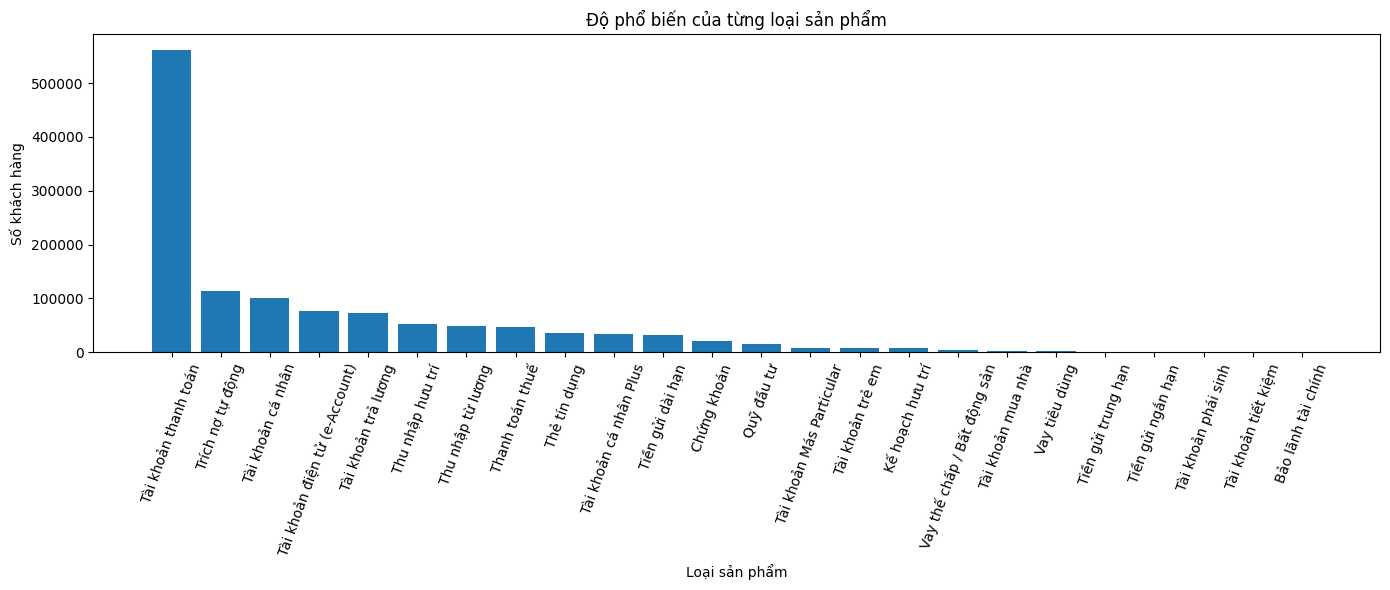

In [33]:
# Độ phổ biến của từng sản phẩm: số khách hàng sở hữu ở snapshot mới nhất.
product_sum_sql = ', '.join(
    f'SUM(COALESCE(TRY_CAST({quote_identifier(column)} AS INTEGER), 0)) AS {quote_identifier(column)}'
    for column in PRODUCT_COLUMNS
)

latest_customer_count = q('''
    SELECT COUNT(DISTINCT ncodpers) AS n
    FROM read_parquet(?)
''', str(TRAIN_PARQUET)).iloc[0, 0]

product_popularity = (
    q(f'''
        WITH latest_snapshot AS (
            SELECT * EXCLUDE (snapshot_rank)
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
                FROM read_parquet(?)
            )
            WHERE snapshot_rank = 1
        )
        SELECT {product_sum_sql} FROM latest_snapshot
    ''', str(TRAIN_PARQUET))
    .T.rename_axis('product_column')
    .reset_index()
    .rename(columns={0: 'customer_count'})
    .assign(
        product=lambda df: df['product_column'].map(PRODUCT_CATALOG).fillna(df['product_column']),
        ratio=lambda df: (df['customer_count'] / latest_customer_count * 100).round(2)
    )
    .sort_values('customer_count', ascending=False)
)

display(product_popularity)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(product_popularity['product'], product_popularity['customer_count'], color='#1f77b4')
ax.set(title='Độ phổ biến của từng loại sản phẩm', xlabel='Loại sản phẩm', ylabel='Số khách hàng')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_count,customer_count,customer_pct
0,0,256447,26.81
1,1,456390,47.71
2,2,120752,12.62
3,3,47837,5.00
4,4,28777,3.01
5,5,18047,1.89
6,6,12689,1.33
7,7,8356,0.87
8,8,4445,0.46
9,9,1897,0.20


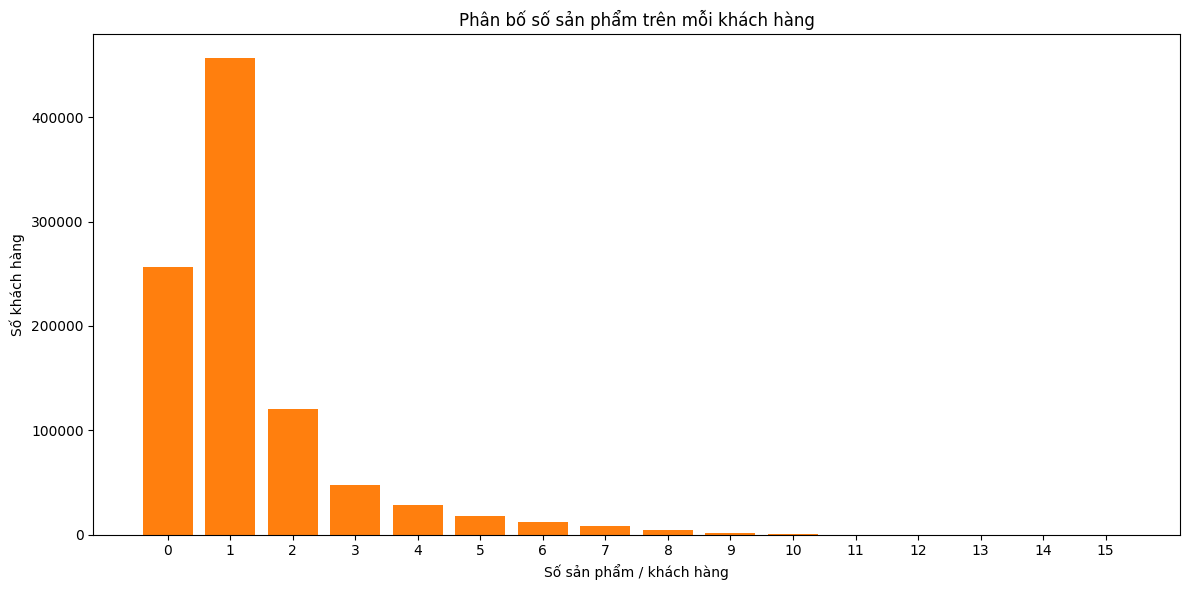

In [34]:
# Phân bố tổng số sản phẩm mà mỗi khách hàng sở hữu ở snapshot mới nhất.
products_per_customer_sql = ' + '.join(
    f'COALESCE(TRY_CAST({quote_identifier(column)} AS INTEGER), 0)'
    for column in PRODUCT_COLUMNS
)

product_count_distribution = q(f'''
    WITH latest_snapshot AS (
        SELECT * EXCLUDE (snapshot_rank)
        FROM (
            SELECT *, ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
            FROM read_parquet(?)
        )
        WHERE snapshot_rank = 1
    ),
    per_customer AS (
        SELECT {products_per_customer_sql} AS product_count
        FROM latest_snapshot
    )
    SELECT
        product_count,
        COUNT(*) AS customer_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS customer_pct
    FROM per_customer
    GROUP BY product_count
    ORDER BY product_count
''', str(TRAIN_PARQUET))

display(product_count_distribution)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(product_count_distribution['product_count'], product_count_distribution['customer_count'], color='#ff7f0e')
ax.set(
    title='Phân bố số sản phẩm trên mỗi khách hàng',
    xlabel='Số sản phẩm / khách hàng',
    ylabel='Số khách hàng',
)
ax.set_xticks(product_count_distribution['product_count'])
plt.tight_layout()
plt.show()


### Chất lượng và tính nhất quán của feature profile theo lịch sử khách hàng

In [35]:
PROFILE_COLUMNS = [
    'age', 'antiguedad', 'renta', 'ind_nuevo', 'indrel', 'indrel_1mes',
    'tiprel_1mes', 'ind_actividad_cliente', 'ind_empleado', 'conyuemp',
    'indfall', 'sexo', 'pais_residencia', 'cod_prov', 'nomprov',
    'canal_entrada', 'segmento', 'fecha_alta', 'ult_fec_cli_1t',
]
PROFILE_COLUMNS = [column for column in PROFILE_COLUMNS if column in ALL_COLUMNS]

profile_validity = q("""
    SELECT
        COUNT(*) AS rows,
        SUM(age IS NULL) AS age_missing,
        SUM(age < 18 OR age > 100) AS implausible_age,
        MIN(age) AS min_age,
        quantile_cont(age, 0.01) AS age_p01,
        quantile_cont(age, 0.5) AS age_median,
        quantile_cont(age, 0.99) AS age_p99,
        MAX(age) AS max_age,
        SUM(antiguedad = -999999) AS tenure_sentinel_count,
        SUM(antiguedad < 0 AND antiguedad <> -999999) AS other_negative_tenure,
        SUM(renta < 0) AS negative_income_count,
        SUM(fecha_alta > fecha_dato) AS join_date_after_snapshot,
        SUM(ult_fec_cli_1t > fecha_dato) AS last_primary_date_after_snapshot
    FROM read_parquet(?)
""", str(TRAIN_PARQUET))
display(profile_validity)

profile_change = q("""
    WITH ordered AS (
        SELECT ncodpers, fecha_dato, age, antiguedad, renta,
               LAG(age) OVER customer_window AS prev_age,
               LAG(antiguedad) OVER customer_window AS prev_tenure,
               LAG(renta) OVER customer_window AS prev_income
        FROM read_parquet(?)
        WINDOW customer_window AS (PARTITION BY ncodpers ORDER BY fecha_dato)
    )
    SELECT
        SUM(prev_age IS NOT NULL AND ABS(age - prev_age) > 2) AS large_age_jumps,
        SUM(prev_tenure IS NOT NULL AND antiguedad < prev_tenure
            AND antiguedad <> -999999 AND prev_tenure <> -999999) AS tenure_decreases,
        SUM(prev_income IS NOT NULL AND renta IS NOT NULL AND prev_income IS NOT NULL
            AND ABS(renta - prev_income) / NULLIF(ABS(prev_income), 0) > 0.5) AS income_changes_over_50pct
    FROM ordered
""", str(TRAIN_PARQUET))
display(profile_change)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,age_missing,implausible_age,min_age,age_p01,age_median,age_p99,max_age,tenure_sentinel_count,other_negative_tenure,negative_income_count,join_date_after_snapshot,last_primary_date_after_snapshot
0,13647309,27734.0,131665.0,2.0,19.0,39.0,88.0,164.0,38.0,0.0,0.0,11586.0,5455.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,large_age_jumps,tenure_decreases,income_changes_over_50pct
0,148.0,2150.0,0.0


#### Insight rút ra được

- Bảng đầu tiên xác định chính xác các giá trị không hợp lệ/sentinel và chronology violation trước khi impute hoặc tạo feature; không suy luận validity chỉ từ distinct count.
- Bảng lịch sử tách thay đổi profile hợp lý khỏi khả năng lỗi dữ liệu. Các biến thay đổi mạnh giữa tháng, đặc biệt `renta`, nên dùng giá trị tại thời điểm dự báo và missing flag thay vì forward-fill vô điều kiện.

### Missingness profile, sự ổn định theo khách hàng và mối quan hệ địa lý

In [36]:
profile_missing_sql = ', '.join(
    f"ROUND(100.0 * SUM({quote_identifier(column)} IS NULL) / COUNT(*), 3) AS {quote_identifier(column)}"
    for column in PROFILE_COLUMNS
)
profile_missing = q(f"SELECT {profile_missing_sql} FROM read_parquet(?)", str(TRAIN_PARQUET)).T
profile_missing.columns = ['missing_pct']
profile_missing.index.name = 'feature'
display(profile_missing.sort_values('missing_pct', ascending=False))

missing_pattern = q("""
    WITH profile_flags AS (
        SELECT
            ncodpers,
            SUM(age IS NULL) AS age_missing,
            SUM(renta IS NULL) AS income_missing,
            SUM(indfall IS NULL) AS death_flag_missing,
            SUM(segmento IS NULL) AS segment_missing,
            COUNT(*) AS snapshots
        FROM read_parquet(?)
        GROUP BY ncodpers
    )
    SELECT
        snapshots,
        COUNT(*) AS customers,
        ROUND(100.0 * AVG(CASE WHEN age_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_age_missing_pct,
        ROUND(100.0 * AVG(CASE WHEN income_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_income_missing_pct,
        ROUND(100.0 * AVG(CASE WHEN death_flag_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_death_flag_missing_pct,
        ROUND(100.0 * AVG(CASE WHEN segment_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_segment_missing_pct
    FROM profile_flags
    GROUP BY snapshots
    ORDER BY snapshots
""", str(TRAIN_PARQUET))
display(missing_pattern)

province_mapping = q("""
    SELECT
        COUNT(*) AS observed_rows,
        COUNT(DISTINCT cod_prov) AS province_codes,
        COUNT(DISTINCT nomprov) AS province_names,
        COUNT(DISTINCT (cod_prov, nomprov)) AS code_name_pairs,
        SUM(cod_prov IS NULL AND nomprov IS NOT NULL) AS code_missing_name_present,
        SUM(cod_prov IS NOT NULL AND nomprov IS NULL) AS name_missing_code_present
    FROM read_parquet(?)
""", str(TRAIN_PARQUET))
display(province_mapping)

province_conflicts = q("""
    SELECT cod_prov, COUNT(DISTINCT nomprov) AS names_per_code, COUNT(*) AS rows
    FROM read_parquet(?)
    WHERE cod_prov IS NOT NULL AND nomprov IS NOT NULL
    GROUP BY cod_prov
    HAVING COUNT(DISTINCT nomprov) > 1
    ORDER BY rows DESC
    LIMIT 20
""", str(TRAIN_PARQUET))
display(province_conflicts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_pct
feature,
conyuemp,99.987
ult_fec_cli_1t,99.818
renta,20.476
segmento,1.388
canal_entrada,1.364
indrel_1mes,1.098
tiprel_1mes,1.098
nomprov,0.686
cod_prov,0.686


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,snapshots,customers,customers_with_age_missing_pct,customers_with_income_missing_pct,customers_with_death_flag_missing_pct,customers_with_segment_missing_pct
0,1,10472,12.07,99.11,12.07,97.67
1,2,7256,13.57,98.61,13.57,97.06
2,3,7000,11.10,98.21,11.10,91.44
3,4,7297,10.17,95.51,10.17,96.63
4,5,8864,17.36,95.27,17.36,96.97
5,6,10012,17.95,92.37,17.95,91.92
6,7,16098,0.24,98.51,0.24,93.87
7,8,28061,0.10,98.94,0.10,96.59
8,9,23470,0.12,55.27,0.12,95.66
9,10,14911,0.21,18.62,0.21,92.66


,observed_rows,province_codes,province_names,code_name_pairs,code_missing_name_present,name_missing_code_present
0,13647309,52,52,53,0.0,0.0


,cod_prov,names_per_code,rows


#### Insight rút ra được

- Missingness được đánh giá ở cả row-level và customer-history level: cùng một tỷ lệ missing tổng có thể là một nhóm khách hàng luôn thiếu profile hoặc là missing ngẫu nhiên theo tháng; hai trường hợp cần chiến lược impute khác nhau.
- `cod_prov` và `nomprov` chỉ nên thay thế/fill chéo nếu bảng conflict rỗng hoặc được giải thích rõ. Khi mapping không một-một, chọn một canonical field và thêm missing indicator.

### Tương quan và association giữa các feature profile

In [37]:
numeric_association = q("""
    SELECT
        corr(age, antiguedad) AS age_tenure_pearson,
        corr(age, renta) AS age_income_pearson,
        corr(antiguedad, renta) AS tenure_income_pearson,
        corr(age, ind_actividad_cliente) AS age_activity_pearson,
        corr(antiguedad, ind_actividad_cliente) AS tenure_activity_pearson,
        corr(renta, ind_actividad_cliente) AS income_activity_pearson
    FROM read_parquet(?)
    WHERE age BETWEEN 18 AND 100
      AND antiguedad >= 0
      AND antiguedad <> -999999
      AND renta >= 0
""", str(TRAIN_PARQUET))
display(numeric_association.T.rename(columns={0: 'pearson_correlation'}))

profile_segment_summary = q("""
    SELECT
        COALESCE(segmento, 'Unknown') AS segmento,
        COUNT(*) AS customer_months,
        ROUND(AVG(age), 2) AS mean_age,
        ROUND(quantile_cont(renta, 0.5), 2) AS median_income,
        ROUND(100.0 * AVG(CASE WHEN ind_actividad_cliente = 1 THEN 1 ELSE 0 END), 2) AS active_pct,
        ROUND(100.0 * AVG(CASE WHEN ind_nuevo = 1 THEN 1 ELSE 0 END), 2) AS new_customer_pct
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY customer_months DESC
""", str(TRAIN_PARQUET))
display(profile_segment_summary)

association_sample = q("""
    WITH sample AS (
        SELECT *
        FROM read_parquet(?)
        WHERE hash(ncodpers) % 100 = 0
    ),
    employee_spouse AS (
        SELECT ind_empleado, conyuemp, COUNT(*) AS n
        FROM sample
        GROUP BY 1, 2
    )
    SELECT *
    FROM employee_spouse
    ORDER BY n DESC
""", str(TRAIN_PARQUET))
display(association_sample)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pearson_correlation
age_tenure_pearson,0.601090
age_income_pearson,0.069417
tenure_income_pearson,0.082240
age_activity_pearson,0.143458
tenure_activity_pearson,0.139944
income_activity_pearson,0.026918


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segmento,customer_months,mean_age,median_income,active_pct,new_customer_pct
0,02 - PARTICULARES,7960220,49.13,108013.648438,52.29,3.22
1,03 - UNIVERSITARIO,4935579,24.22,88740.273438,29.88,8.00
2,01 - TOP,562142,55.10,141562.687500,98.43,4.28
3,Unknown,189368,35.02,100257.093750,23.70,71.69


,ind_empleado,conyuemp,n
0,N,None,138144
1,None,None,271
2,F,None,51
3,B,None,51
4,A,None,28
5,B,N,17
6,N,N,2


#### Insight rút ra được

- Pearson correlation chỉ là kiểm tra tuyến tính cho numeric feature sau khi loại sentinel/range không hợp lý; không dùng nó để kết luận quan hệ nhân quả hoặc loại feature categorical.
- Bảng segment cho thấy khác biệt profile và hoạt động theo phân khúc; chỉ sử dụng interaction đã được xác nhận bằng temporal validation. Bảng `ind_empleado × conyuemp` kiểm tra trực tiếp giả thuyết về cờ vợ/chồng nhân viên trên sample xác định, không cần quét/cross-tab toàn bộ dữ liệu nhiều lần.

## 6. Split and leakage checks
Compare train and test schemas, identifiers, time ranges, common numeric distributions, and unseen category values to flag split mismatch or potential leakage.

In [257]:
# Explicit feature lists keep this cell runnable independently of prior exploratory cells.
numeric_features = [c for c in ["age", "antiguedad", "renta"] if c in ALL_COLUMNS]
category_columns_to_check = [
    c for c in [
        "ind_empleado", "pais_residencia", "sexo", "indrel_1mes",
        "tiprel_1mes", "canal_entrada", "indfall", "nomprov", "segmento",
    ] if c in ALL_COLUMNS
]

if TEST_COLUMNS is None:
    print('Test checkpoint is unavailable; train/test comparison skipped.')
else:
    train_schema = TRAIN_COLUMNS[['column_name', 'column_type']].rename(columns={'column_type': 'train_type'})
    test_schema = TEST_COLUMNS[['column_name', 'column_type']].rename(columns={'column_type': 'test_type'})
    schema_comparison = train_schema.merge(test_schema, on='column_name', how='outer', indicator=True)
    display(schema_comparison.sort_values(['_merge', 'column_name']))
    print('Train-only columns are normally product-state columns. Any other train-only field needs review.')

    common_numeric = [c for c in numeric_features if c in set(TEST_COLUMNS.column_name)]
    numeric_shift_rows = []
    for column in common_numeric:
        col = quote_identifier(column)
        train_stats = q(f'SELECT AVG({col}) AS mean, quantile_cont({col}, 0.5) AS median, COUNT({col}) AS non_null FROM read_parquet(?)', str(TRAIN_PARQUET)).iloc[0].to_dict()
        test_stats = q(f'SELECT AVG({col}) AS mean, quantile_cont({col}, 0.5) AS median, COUNT({col}) AS non_null FROM read_parquet(?)', str(TEST_PARQUET)).iloc[0].to_dict()
        numeric_shift_rows.append({'feature': column, **{f'train_{k}': v for k, v in train_stats.items()}, **{f'test_{k}': v for k, v in test_stats.items()}})
    display(pd.DataFrame(numeric_shift_rows))

    if 'ncodpers' in set(TEST_COLUMNS.column_name):
        display(q('''
            SELECT COUNT(*) AS overlapping_customer_ids
            FROM (SELECT DISTINCT ncodpers FROM read_parquet(?)) train_ids
            INNER JOIN (SELECT DISTINCT ncodpers FROM read_parquet(?)) test_ids USING (ncodpers)
        ''', str(TRAIN_PARQUET), str(TEST_PARQUET)))

    if 'fecha_dato' in set(TEST_COLUMNS.column_name):
        display(q("SELECT 'train' AS split, MIN(fecha_dato) AS min_date, MAX(fecha_dato) AS max_date FROM read_parquet(?) UNION ALL SELECT 'test', MIN(fecha_dato), MAX(fecha_dato) FROM read_parquet(?)", str(TRAIN_PARQUET), str(TEST_PARQUET)))

    shared_categories = [c for c in category_columns_to_check if c in set(TEST_COLUMNS.column_name)]
    unseen_category_rows = []
    for column in shared_categories:
        col = quote_identifier(column)
        unseen = q(f'''
            SELECT COUNT(*) AS unseen_test_categories
            FROM (SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL) test_values
            WHERE {col} NOT IN (SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL)
        ''', str(TEST_PARQUET), str(TRAIN_PARQUET)).iloc[0, 0]
        unseen_category_rows.append({'feature': column, 'unseen_test_categories': unseen})
    display(pd.DataFrame(unseen_category_rows))

    leakage_candidates = [c for c in ALL_COLUMNS if c in PRODUCT_COLUMNS or c.startswith('fecha_') or c == 'ult_fec_cli_1t']
    print('Review before modelling: these columns may encode current/future product state or timing:', leakage_candidates)


,column_name,train_type,test_type,_merge
8,ind_ahor_fin_ult1,TINYINT,NaN,left_only
9,ind_aval_fin_ult1,TINYINT,NaN,left_only
10,ind_cco_fin_ult1,TINYINT,NaN,left_only
11,ind_cder_fin_ult1,TINYINT,NaN,left_only
12,ind_cno_fin_ult1,TINYINT,NaN,left_only
13,ind_ctju_fin_ult1,TINYINT,NaN,left_only
14,ind_ctma_fin_ult1,TINYINT,NaN,left_only
15,ind_ctop_fin_ult1,TINYINT,NaN,left_only
16,ind_ctpp_fin_ult1,TINYINT,NaN,left_only
17,ind_deco_fin_ult1,TINYINT,NaN,left_only


Train-only columns are normally product-state columns. Any other train-only field needs review.


,feature,train_mean,train_median,train_non_null,test_mean,test_median,test_non_null
0,age,40.181465,39.0,13619575.0,40.249821,39.000000,929615.0
1,antiguedad,76.591941,50.0,13619575.0,77.728413,55.000000,929615.0
2,renta,134254.318212,101850.0,10852934.0,134087.870565,101490.515625,701650.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,overlapping_customer_ids
0,929615


,split,min_date,max_date
0,train,2015-01-28,2016-05-28
1,test,2016-06-28,2016-06-28


,feature,unseen_test_categories
0,ind_empleado,0
1,pais_residencia,0
2,sexo,0
3,indrel_1mes,0
4,tiprel_1mes,0
5,canal_entrada,0
6,indfall,0
7,nomprov,0
8,segmento,0


Review before modelling: these columns may encode current/future product state or timing: ['fecha_dato', 'fecha_alta', 'ult_fec_cli_1t', 'ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1', 'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1', 'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1', 'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1', 'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1', 'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1', 'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1']


# Feature Deep EDA

Feature-level dossiers for customer profile variables: missingness diagnostics, distribution, encoding/outlier decisions, and association screening.

In [273]:
# Logic: define feature metadata, valid ranges, and candidate relationships used by the feature dossiers.
# Feature Deep EDA — configuration
from __future__ import annotations

from typing import Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "TRAIN_PARQUET" not in globals() or "q" not in globals():
    raise RuntimeError("Run the existing 'EDA setup' cell before this section.")

# Standalone fallback: the previous profile-quality cell may be skipped while iterating.
DEFAULT_PROFILE_COLUMNS = [
    "age", "antiguedad", "renta", "ind_nuevo", "indrel", "indrel_1mes",
    "tiprel_1mes", "ind_actividad_cliente", "ind_empleado", "conyuemp",
    "indfall", "sexo", "pais_residencia", "cod_prov", "nomprov",
    "canal_entrada", "segmento", "fecha_alta", "ult_fec_cli_1t",
]
PROFILE_COLUMNS = [c for c in globals().get("PROFILE_COLUMNS", DEFAULT_PROFILE_COLUMNS) if c in ALL_COLUMNS]
PROFILE_NUMERIC = {"age", "antiguedad", "renta"}
PROFILE_DATES = {"fecha_alta", "ult_fec_cli_1t"}
PROFILE_ORDINAL = {"ind_nuevo", "indrel", "indrel_1mes", "ind_actividad_cliente"}
VALID_RANGES = {"age": (18, 100), "antiguedad": (0, None), "renta": (0, None)}
TOP_LEVELS = 15
ASSOCIATION_SAMPLE_MOD = 100  # deterministic ~1% customer sample; preserves full customer histories

FEATURE_PARTNERS = {
    "age": ["renta", "antiguedad", "segmento", "ind_nuevo"],
    "antiguedad": ["fecha_alta", "age", "ind_nuevo", "indrel_1mes"],
    "renta": ["age", "segmento", "cod_prov", "ind_actividad_cliente"],
    "ind_nuevo": ["antiguedad", "fecha_alta", "age", "canal_entrada"],
    "indrel": ["indrel_1mes", "tiprel_1mes", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "indrel_1mes": ["indrel", "tiprel_1mes", "ind_actividad_cliente", "ind_nuevo"],
    "tiprel_1mes": ["indrel_1mes", "indrel", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "ind_actividad_cliente": ["tiprel_1mes", "indrel_1mes", "segmento", "canal_entrada"],
    "ind_empleado": ["conyuemp", "canal_entrada", "segmento", "renta"],
    "conyuemp": ["ind_empleado", "sexo", "indfall", "segmento"],
    "indfall": ["ind_actividad_cliente", "tiprel_1mes", "indrel_1mes", "ult_fec_cli_1t"],
    "sexo": ["age", "renta", "segmento", "canal_entrada"],
    "pais_residencia": ["indresi", "indext", "cod_prov", "canal_entrada"],
    "cod_prov": ["nomprov", "renta", "segmento", "canal_entrada"],
    "nomprov": ["cod_prov", "renta", "segmento", "canal_entrada"],
    "canal_entrada": ["segmento", "ind_nuevo", "ind_actividad_cliente", "ind_empleado"],
    "segmento": ["renta", "age", "ind_actividad_cliente", "canal_entrada"],
    "fecha_alta": ["antiguedad", "ind_nuevo", "age", "canal_entrada"],
    "ult_fec_cli_1t": ["indrel", "indrel_1mes", "tiprel_1mes", "indfall"],
}
HISTORY_FILL_CANDIDATES = {"age", "fecha_alta", "sexo", "pais_residencia", "cod_prov", "nomprov"}
TYPE_BY_COLUMN = dict(zip(TRAIN_COLUMNS["column_name"], TRAIN_COLUMNS["column_type"]))

def feature_kind(feature: str) -> str:
    if feature in PROFILE_NUMERIC:
        return "numeric"
    if feature in PROFILE_DATES:
        return "date"
    if feature in PROFILE_ORDINAL:
        return "ordinal"
    return "categorical"

def col_sql(feature: str) -> str:
    return quote_identifier(feature)

def label_expr(feature: str) -> str:
    return f"COALESCE(CAST({col_sql(feature)} AS VARCHAR), '__MISSING__')"

def numeric_expr(feature: str) -> str:
    return f"TRY_CAST({col_sql(feature)} AS DOUBLE)"

def cramer_v_from_counts(counts: pd.DataFrame) -> float:
    matrix = counts.to_numpy(dtype=float)
    if matrix.size == 0 or min(matrix.shape) < 2:
        return np.nan
    total = matrix.sum()
    expected = np.outer(matrix.sum(axis=1), matrix.sum(axis=0)) / total
    chi2 = np.divide((matrix - expected) ** 2, expected, out=np.zeros_like(matrix), where=expected > 0).sum()
    return float(np.sqrt((chi2 / total) / min(matrix.shape[0] - 1, matrix.shape[1] - 1)))

In [274]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
# Feature Deep EDA — shared helpers for separated, feature-by-feature cells
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "TRAIN_PARQUET" not in globals() or "q" not in globals():
    raise RuntimeError("Run the existing EDA setup cell before this section.")

PROFILE_COLUMNS = [c for c in [
    "age", "antiguedad", "renta", "ind_nuevo", "indrel", "indrel_1mes",
    "tiprel_1mes", "ind_actividad_cliente", "ind_empleado", "conyuemp",
    "indfall", "sexo", "pais_residencia", "cod_prov", "nomprov",
    "canal_entrada", "segmento", "fecha_alta", "ult_fec_cli_1t",
] if c in ALL_COLUMNS]
NUMERIC_PROFILE_COLUMNS = {"age", "antiguedad", "renta"}
TOP_LEVELS = 15

FEATURE_PARTNERS = {
    "age": ["antiguedad", "renta", "segmento", "ind_nuevo"],
    "antiguedad": ["age", "fecha_alta", "ind_nuevo", "indrel_1mes"],
    "renta": ["age", "segmento", "cod_prov", "ind_actividad_cliente"],
    "ind_nuevo": ["antiguedad", "fecha_alta", "age", "canal_entrada"],
    "indrel": ["indrel_1mes", "tiprel_1mes", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "indrel_1mes": ["indrel", "tiprel_1mes", "ind_actividad_cliente", "ind_nuevo"],
    "tiprel_1mes": ["indrel_1mes", "indrel", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "ind_actividad_cliente": ["tiprel_1mes", "indrel_1mes", "segmento", "canal_entrada"],
    "ind_empleado": ["conyuemp", "canal_entrada", "segmento", "renta"],
    "conyuemp": ["ind_empleado", "sexo", "indfall", "segmento"],
    "indfall": ["ind_actividad_cliente", "tiprel_1mes", "indrel_1mes", "ult_fec_cli_1t"],
    "sexo": ["age", "renta", "segmento", "canal_entrada"],
    "pais_residencia": ["cod_prov", "nomprov", "canal_entrada", "segmento"],
    "cod_prov": ["nomprov", "renta", "segmento", "canal_entrada"],
    "nomprov": ["cod_prov", "renta", "segmento", "canal_entrada"],
    "canal_entrada": ["segmento", "ind_nuevo", "ind_actividad_cliente", "ind_empleado"],
    "segmento": ["renta", "age", "ind_actividad_cliente", "canal_entrada"],
    "fecha_alta": ["antiguedad", "ind_nuevo", "age", "canal_entrada"],
    "ult_fec_cli_1t": ["indrel", "indrel_1mes", "tiprel_1mes", "indfall"],
}

def F(feature: str) -> str:
    return quote_identifier(feature)

def value_label(feature: str) -> str:
    return f"COALESCE(CAST({F(feature)} AS VARCHAR), '__MISSING__')"

def deep_overview(feature: str) -> pd.DataFrame:
    return q(f"""
        SELECT COUNT(*) AS rows,
               SUM({F(feature)} IS NULL) AS missing_count,
               ROUND(100.0 * AVG(CASE WHEN {F(feature)} IS NULL THEN 1 ELSE 0 END), 3) AS missing_pct,
               COUNT(DISTINCT {F(feature)}) AS n_unique_non_null
        FROM read_parquet(?)
    """, str(TRAIN_PARQUET))

def deep_missing_by_month(feature: str) -> pd.DataFrame:
    return q(f"""
        SELECT fecha_dato, COUNT(*) AS rows, SUM({F(feature)} IS NULL) AS missing_count,
               ROUND(100.0 * AVG(CASE WHEN {F(feature)} IS NULL THEN 1 ELSE 0 END), 3) AS missing_pct
        FROM read_parquet(?) GROUP BY 1 ORDER BY 1
    """, str(TRAIN_PARQUET))

def deep_history_missing(feature: str) -> pd.DataFrame:
    return q(f"""
        WITH ordered AS (
            SELECT ncodpers, fecha_dato, {F(feature)} IS NULL AS is_missing,
                   MAX(CASE WHEN {F(feature)} IS NOT NULL THEN 1 ELSE 0 END) OVER (
                       PARTITION BY ncodpers ORDER BY fecha_dato
                       ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
                   ) AS observed_before
            FROM read_parquet(?)
        )
        SELECT SUM(is_missing) AS missing_rows,
               SUM(is_missing AND COALESCE(observed_before, 0) = 1) AS missing_after_observed,
               ROUND(100.0 * SUM(is_missing AND COALESCE(observed_before, 0) = 1)
                     / NULLIF(SUM(is_missing), 0), 2) AS pct_after_observed
        FROM ordered
    """, str(TRAIN_PARQUET))

def deep_missing_by_driver(feature: str, driver: str) -> pd.DataFrame:
    return q(f"""
        SELECT {value_label(driver)} AS {quote_identifier(driver)},
               COUNT(*) AS rows,
               SUM({F(feature)} IS NULL) AS missing_count,
               ROUND(100.0 * AVG(CASE WHEN {F(feature)} IS NULL THEN 1 ELSE 0 END), 3) AS missing_pct
        FROM read_parquet(?)
        GROUP BY 1
        ORDER BY rows DESC, missing_pct DESC
        LIMIT {TOP_LEVELS}
    """, str(TRAIN_PARQUET))

def deep_numeric_describe(feature: str) -> pd.DataFrame:
    x = f"TRY_CAST({F(feature)} AS DOUBLE)"
    return q(f"""
        WITH v AS (SELECT {x} AS x FROM read_parquet(?) WHERE {x} IS NOT NULL),
        b AS (SELECT quantile_cont(x,.01) p01, quantile_cont(x,.25) q1, quantile_cont(x,.5) median,
                     quantile_cont(x,.75) q3, quantile_cont(x,.99) p99 FROM v)
        SELECT COUNT(*) AS non_null_count, MIN(x) AS min_value, AVG(x) AS mean_value,
               STDDEV_SAMP(x) AS std_value, b.p01, b.q1, b.median, b.q3, b.p99, MAX(x) AS max_value,
               SUM(CASE WHEN x < b.q1-1.5*(b.q3-b.q1) OR x > b.q3+1.5*(b.q3-b.q1) THEN 1 ELSE 0 END) AS iqr_outlier_count,
               ROUND(100.0 * AVG(CASE WHEN x < b.q1-1.5*(b.q3-b.q1) OR x > b.q3+1.5*(b.q3-b.q1) THEN 1 ELSE 0 END), 3) AS iqr_outlier_pct
        FROM v CROSS JOIN b GROUP BY b.p01,b.q1,b.median,b.q3,b.p99
    """, str(TRAIN_PARQUET))

def deep_top_values(feature: str) -> pd.DataFrame:
    return q(f"""
        SELECT {value_label(feature)} AS value, COUNT(*) AS rows,
               ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),3) AS pct
        FROM read_parquet(?) GROUP BY 1 ORDER BY rows DESC, value LIMIT {TOP_LEVELS}
    """, str(TRAIN_PARQUET))

def deep_association_table(feature: str) -> pd.DataFrame:
    partners = [p for p in FEATURE_PARTNERS.get(feature, []) if p in ALL_COLUMNS]
    if feature in NUMERIC_PROFILE_COLUMNS:
        rows = []
        for partner in partners:
            if partner not in NUMERIC_PROFILE_COLUMNS:
                continue
            score = q(f"""
                SELECT corr(x_rank,y_rank) AS spearman_rho FROM (
                    SELECT RANK() OVER (ORDER BY x) AS x_rank, RANK() OVER (ORDER BY y) AS y_rank
                    FROM (
                        SELECT TRY_CAST({F(feature)} AS DOUBLE) AS x, TRY_CAST({F(partner)} AS DOUBLE) AS y
                        FROM read_parquet(?)
                        WHERE hash(ncodpers) % 100 = 0
                          AND TRY_CAST({F(feature)} AS DOUBLE) IS NOT NULL
                          AND TRY_CAST({F(partner)} AS DOUBLE) IS NOT NULL
                    )
                )
            """, str(TRAIN_PARQUET)).iloc[0, 0]
            rows.append({"partner": partner, "measure": "Spearman rho", "score": score})
        return pd.DataFrame(rows)
    # For categorical/temporal variables, show compatible partner levels instead of misleading Pearson correlation.
    return pd.DataFrame({"candidate_partner": partners,
                         "how_to_combine": ["Validate as an interaction with time-based split."] * len(partners)})

In [275]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
# Feature Deep EDA — insight renderers (always derived from the cell outputs)
from IPython.display import Markdown, display

def show_overview_insight(feature: str, overview: pd.DataFrame) -> None:
    row = overview.iloc[0]
    display(Markdown(
        f"**Insight.** {feature} có **{int(row.missing_count):,}** giá trị thiếu "
        f"(**{row.missing_pct:.3f}%**) và **{int(row.n_unique_non_null):,}** giá trị khác nhau (không tính null). "
        "Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation."
    ))

def show_missing_insight(feature: str, history: pd.DataFrame, driver: str) -> None:
    row = history.iloc[0]
    if pd.isna(row.pct_after_observed):
        decision = "Không có missing vật lý, nên không cần imputation."
    elif feature in {"age", "fecha_alta", "sexo", "pais_residencia", "cod_prov", "nomprov"} and row.pct_after_observed >= 70:
        decision = "Forward-fill theo ncodpers từ các tháng trước là ứng viên hợp lý; vẫn giữ cờ missing gốc."
    elif feature in NUMERIC_PROFILE_COLUMNS:
        decision = "Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện."
    else:
        decision = "Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng."
    display(Markdown(
        f"**Insight.** Có **{int(row.missing_rows):,}** missing; **{row.pct_after_observed if pd.notna(row.pct_after_observed) else 0:.2f}%** "
        f"xảy ra sau một quan sát hợp lệ trước đó. Bảng theo {driver} là kiểm chứng giả thuyết missing theo nhóm. {decision}"
    ))

def show_distribution_insight(feature: str, kind: str, values: pd.DataFrame) -> None:
    if kind == "numeric":
        row = values.iloc[0]
        display(Markdown(
            f"**Insight.** Median = **{row["median"]:,.2f}**, P01–P99 = **{row["p01"]:,.2f}–{row["p99"]:,.2f}**; "
            f"**{row["iqr_outlier_pct"]:.3f}%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; "
            "chỉ tạo bins như feature bổ sung khi temporal validation có lợi."
        ))
    else:
        top = values.iloc[0]
        display(Markdown(
            f"**Insight.** Giá trị phổ biến nhất là {top.value} với **{top.pct:.3f}%**. "
            "Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding."
        ))

def show_association_insight(feature: str, associations: pd.DataFrame) -> None:
    if associations.empty:
        text = "Không có association định lượng phù hợp trong danh sách ứng viên; giữ các cặp theo domain để kiểm tra bằng temporal validation."
    elif "score" in associations:
        top = associations.iloc[0]
        text = f"Association mạnh nhất trong các ứng viên là {top.partner} ({top.measure} = **{top.score:.3f}**). Đây là ứng viên interaction, không phải bằng chứng nhân quả."
    else:
        text = "Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện."
    display(Markdown("**Insight.** " + text))

### age — Tuổi khách hàng

Biến numeric; kiểm tra missing, phân phối, domain validity, outlier và các interaction ứng viên.

In [276]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
age_overview = deep_overview("age")
display(age_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,120


**Insight — completeness & cardinality**

In [277]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("age", age_overview)

**Insight.** age có **27,734** giá trị thiếu (**0.203%**) và **120** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [278]:
# Logic: test whether missingness changes by monthly snapshot.
age_missing_by_month = deep_missing_by_month("age")
display(age_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [279]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
age_history_missing = deep_history_missing("age")
display(age_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [280]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
age_missing_by_segmento = deep_missing_by_driver("age", "segmento")
display(age_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,0.0,0.000
1,03 - UNIVERSITARIO,4935579,0.0,0.000
2,01 - TOP,562142,0.0,0.000
3,__MISSING__,189368,27734.0,14.646


**Insight — missingness hypothesis and treatment**

In [281]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("age", age_history_missing, "segmento")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện.

In [282]:
# Logic: calculate robust numeric summary statistics and Tukey-fence outlier rate.
age_describe = deep_numeric_describe("age")
display(age_describe)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,non_null_count,min_value,mean_value,std_value,p01,q1,median,q3,p99,max_value,iqr_outlier_count,iqr_outlier_pct
0,13619575,2.0,40.181465,17.185087,19.0,24.0,39.0,50.0,88.0,164.0,113291.0,0.832


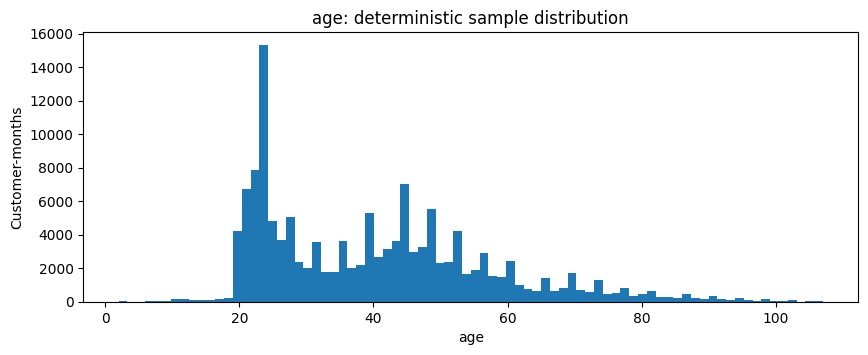

In [283]:
# Logic: draw the numeric distribution on a deterministic customer sample to make shape and tails visible.
_sample_age = q("SELECT TRY_CAST(age AS DOUBLE) AS value FROM read_parquet(?) WHERE hash(ncodpers) % 100 = 0 AND TRY_CAST(age AS DOUBLE) IS NOT NULL LIMIT 200000", str(TRAIN_PARQUET))
ax = _sample_age["value"].plot.hist(bins=80, figsize=(10, 3.5), color="#1f77b4", title="age: deterministic sample distribution")
ax.set(xlabel="age", ylabel="Customer-months")
plt.show()

**Insight — distribution, outliers and transformation**

In [485]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("age", "numeric", age_describe)

**Insight.** Median = **39.00**, P01–P99 = **19.00–88.00**; **0.832%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; chỉ tạo bins như feature bổ sung khi temporal validation có lợi.

In [285]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
age_associations = deep_association_table("age")
display(age_associations)

,partner,measure,score
0,antiguedad,Spearman rho,0.639557
1,renta,Spearman rho,0.177500


#### Tổng hợp, kết luận — age

In [286]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("age", age_associations)

**Insight.** Association mạnh nhất trong các ứng viên là antiguedad (Spearman rho = **0.640**). Đây là ứng viên interaction, không phải bằng chứng nhân quả.

### antiguedad — Thâm niên với ngân hàng

Biến numeric; kiểm tra missing, phân phối, domain validity, outlier và các interaction ứng viên.

In [287]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
antiguedad_overview = deep_overview("antiguedad")
display(antiguedad_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,258


**Insight — completeness & cardinality**

In [288]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("antiguedad", antiguedad_overview)

**Insight.** antiguedad có **27,734** giá trị thiếu (**0.203%**) và **258** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [289]:
# Logic: test whether missingness changes by monthly snapshot.
antiguedad_missing_by_month = deep_missing_by_month("antiguedad")
display(antiguedad_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [290]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
antiguedad_history_missing = deep_history_missing("antiguedad")
display(antiguedad_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [291]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
antiguedad_missing_by_ind_nuevo = deep_missing_by_driver("antiguedad", "ind_nuevo")
display(antiguedad_missing_by_ind_nuevo)

,ind_nuevo,rows,missing_count,missing_pct
0,0,12808368,0.0,0.0
1,1,811207,0.0,0.0
2,__MISSING__,27734,27734.0,100.0


**Insight — missingness hypothesis and treatment**

In [292]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("antiguedad", antiguedad_history_missing, "ind_nuevo")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_nuevo là kiểm chứng giả thuyết missing theo nhóm. Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện.

In [293]:
# Logic: calculate robust numeric summary statistics and Tukey-fence outlier rate.
antiguedad_describe = deep_numeric_describe("antiguedad")
display(antiguedad_describe)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,non_null_count,min_value,mean_value,std_value,p01,q1,median,q3,p99,max_value,iqr_outlier_count,iqr_outlier_pct
0,13619575,-999999.0,76.591941,1671.806547,1.0,23.0,50.0,135.0,232.0,256.0,38.0,0.0


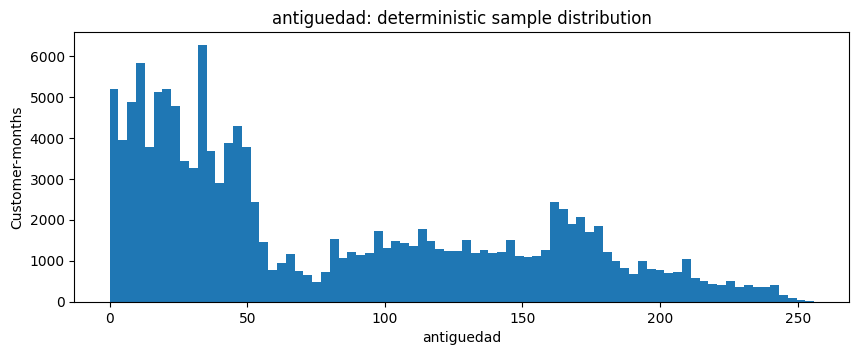

In [294]:
# Logic: draw the numeric distribution on a deterministic customer sample to make shape and tails visible.
_sample_antiguedad = q("SELECT TRY_CAST(antiguedad AS DOUBLE) AS value FROM read_parquet(?) WHERE hash(ncodpers) % 100 = 0 AND TRY_CAST(antiguedad AS DOUBLE) IS NOT NULL LIMIT 200000", str(TRAIN_PARQUET))
ax = _sample_antiguedad["value"].plot.hist(bins=80, figsize=(10, 3.5), color="#1f77b4", title="antiguedad: deterministic sample distribution")
ax.set(xlabel="antiguedad", ylabel="Customer-months")
plt.show()

**Insight — distribution, outliers and transformation**

In [295]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("antiguedad", "numeric", antiguedad_describe)

**Insight.** Median = **50.00**, P01–P99 = **1.00–232.00**; **0.000%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; chỉ tạo bins như feature bổ sung khi temporal validation có lợi.

In [296]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
antiguedad_associations = deep_association_table("antiguedad")
display(antiguedad_associations)

,partner,measure,score
0,age,Spearman rho,0.639557


#### Tổng hợp, kết luận — antiguedad

In [297]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("antiguedad", antiguedad_associations)

**Insight.** Association mạnh nhất trong các ứng viên là age (Spearman rho = **0.640**). Đây là ứng viên interaction, không phải bằng chứng nhân quả.

### renta — Thu nhập gộp hàng năm

Biến numeric; kiểm tra missing, phân phối, domain validity, outlier và các interaction ứng viên.

In [298]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
renta_overview = deep_overview("renta")
display(renta_overview)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,2794375.0,20.476,520988


**Insight — completeness & cardinality**

In [299]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("renta", renta_overview)

**Insight.** renta có **2,794,375** giá trị thiếu (**20.476%**) và **520,988** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [300]:
# Logic: test whether missingness changes by monthly snapshot.
renta_missing_by_month = deep_missing_by_month("renta")
display(renta_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,111578.0,17.839
1,2015-02-28,627394,111119.0,17.711
2,2015-03-28,629209,110709.0,17.595
3,2015-04-28,630367,110262.0,17.492
4,2015-05-28,631957,109919.0,17.393
5,2015-06-28,632110,108439.0,17.155
6,2015-07-28,829817,142540.0,17.177
7,2015-08-28,843201,144237.0,17.106
8,2015-09-28,865440,156029.0,18.029
9,2015-10-28,892251,183316.0,20.545


In [301]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
renta_history_missing = deep_history_missing("renta")
display(renta_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,2794375.0,0.0,0.0


In [302]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
renta_missing_by_segmento = deep_missing_by_driver("renta", "segmento")
display(renta_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,1437342.0,18.057
1,03 - UNIVERSITARIO,4935579,1142131.0,23.141
2,01 - TOP,562142,82367.0,14.652
3,__MISSING__,189368,132535.0,69.988


**Insight — missingness hypothesis and treatment**

In [303]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("renta", renta_history_missing, "segmento")

**Insight.** Có **2,794,375** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện.

In [304]:
# Logic: calculate robust numeric summary statistics and Tukey-fence outlier rate.
renta_describe = deep_numeric_describe("renta")
display(renta_describe)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,non_null_count,min_value,mean_value,std_value,p01,q1,median,q3,p99,max_value,iqr_outlier_count,iqr_outlier_pct
0,10852934,1202.72998,134254.318212,230620.237638,26449.650391,68710.976562,101850.0,155955.953125,554795.0,28894396.0,659391.0,6.076


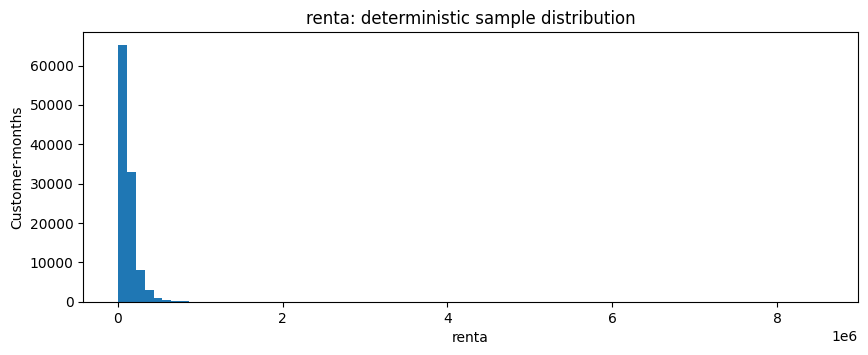

In [305]:
# Logic: draw the numeric distribution on a deterministic customer sample to make shape and tails visible.
_sample_renta = q("SELECT TRY_CAST(renta AS DOUBLE) AS value FROM read_parquet(?) WHERE hash(ncodpers) % 100 = 0 AND TRY_CAST(renta AS DOUBLE) IS NOT NULL LIMIT 200000", str(TRAIN_PARQUET))
ax = _sample_renta["value"].plot.hist(bins=80, figsize=(10, 3.5), color="#1f77b4", title="renta: deterministic sample distribution")
ax.set(xlabel="renta", ylabel="Customer-months")
plt.show()

**Insight — distribution, outliers and transformation**

In [306]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("renta", "numeric", renta_describe)

**Insight.** Median = **101,850.00**, P01–P99 = **26,449.65–554,795.00**; **6.076%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; chỉ tạo bins như feature bổ sung khi temporal validation có lợi.

In [307]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
renta_associations = deep_association_table("renta")
display(renta_associations)

,partner,measure,score
0,age,Spearman rho,0.1775


#### Tổng hợp, kết luận — renta

In [308]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("renta", renta_associations)

**Insight.** Association mạnh nhất trong các ứng viên là age (Spearman rho = **0.177**). Đây là ứng viên interaction, không phải bằng chứng nhân quả.

### conyuemp — Vợ/chồng là nhân viên ngân hàng

Biến categorical; kiểm tra missing, mức giá trị, phân phối và cách encode.

In [309]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
conyuemp_overview = deep_overview("conyuemp")
display(conyuemp_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,13645501.0,99.987,2


**Insight — completeness & cardinality**

In [310]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("conyuemp", conyuemp_overview)

**Insight.** conyuemp có **13,645,501** giá trị thiếu (**99.987%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [311]:
# Logic: test whether missingness changes by monthly snapshot.
conyuemp_missing_by_month = deep_missing_by_month("conyuemp")
display(conyuemp_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,625368.0,99.986
1,2015-02-28,627394,627305.0,99.986
2,2015-03-28,629209,629122.0,99.986
3,2015-04-28,630367,630280.0,99.986
4,2015-05-28,631957,631869.0,99.986
5,2015-06-28,632110,632021.0,99.986
6,2015-07-28,829817,829698.0,99.986
7,2015-08-28,843201,843084.0,99.986
8,2015-09-28,865440,865320.0,99.986
9,2015-10-28,892251,892138.0,99.987


In [312]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
conyuemp_history_missing = deep_history_missing("conyuemp")
display(conyuemp_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,13645501.0,895.0,0.01


In [313]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
conyuemp_missing_by_ind_empleado = deep_missing_by_driver("conyuemp", "ind_empleado")
display(conyuemp_missing_by_ind_empleado)

,ind_empleado,rows,missing_count,missing_pct
0,N,13610977,13610361.0,99.995
1,__MISSING__,27734,27734.0,100.000
2,B,3566,2981.0,83.595
3,F,2523,2086.0,82.679
4,A,2492,2322.0,93.178
5,S,17,17.0,100.000


**Insight — missingness hypothesis and treatment**

In [314]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("conyuemp", conyuemp_history_missing, "ind_empleado")

**Insight.** Có **13,645,501** missing; **0.01%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_empleado là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [315]:
# Logic: count the most frequent categorical/date values, including physical missingness.
conyuemp_values = deep_top_values("conyuemp")
display(conyuemp_values)

,value,rows,pct
0,__MISSING__,13645501,99.987
1,N,1791,0.013
2,S,17,0.000


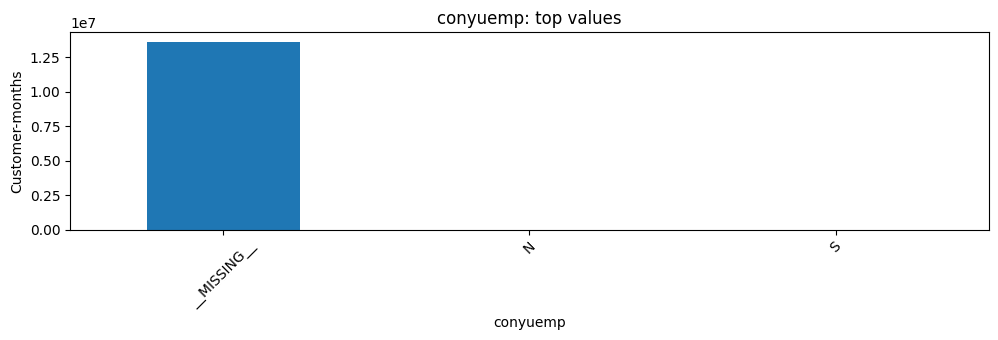

In [316]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = conyuemp_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="conyuemp: top values")
ax.set(xlabel="conyuemp", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [486]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("conyuemp", "categorical", conyuemp_values)

**Insight.** Giá trị phổ biến nhất là __MISSING__ với **99.987%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [318]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
conyuemp_associations = deep_association_table("conyuemp")
display(conyuemp_associations)

,candidate_partner,how_to_combine
0,ind_empleado,Validate as an interaction with time-based split.
1,sexo,Validate as an interaction with time-based split.
2,indfall,Validate as an interaction with time-based split.
3,segmento,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — conyuemp

In [319]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("conyuemp", conyuemp_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ind_nuevo — Cờ khách hàng mới

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [320]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ind_nuevo_overview = deep_overview("ind_nuevo")
display(ind_nuevo_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [321]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ind_nuevo", ind_nuevo_overview)

**Insight.** ind_nuevo có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [322]:
# Logic: test whether missingness changes by monthly snapshot.
ind_nuevo_missing_by_month = deep_missing_by_month("ind_nuevo")
display(ind_nuevo_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [323]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ind_nuevo_history_missing = deep_history_missing("ind_nuevo")
display(ind_nuevo_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [324]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ind_nuevo_missing_by_antiguedad = deep_missing_by_driver("ind_nuevo", "antiguedad")
display(ind_nuevo_missing_by_antiguedad)

,antiguedad,rows,missing_count,missing_pct
0,12,243160,0.0,0.0
1,21,214795,0.0,0.0
2,10,206165,0.0,0.0
3,9,177957,0.0,0.0
4,23,177839,0.0,0.0
5,33,174352,0.0,0.0
6,45,168847,0.0,0.0
7,24,167059,0.0,0.0
8,36,164425,0.0,0.0
9,8,155703,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [325]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ind_nuevo", ind_nuevo_history_missing, "antiguedad")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo antiguedad là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [326]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ind_nuevo_values = deep_top_values("ind_nuevo")
display(ind_nuevo_values)

,value,rows,pct
0,0,12808368,93.853
1,1,811207,5.944
2,__MISSING__,27734,0.203


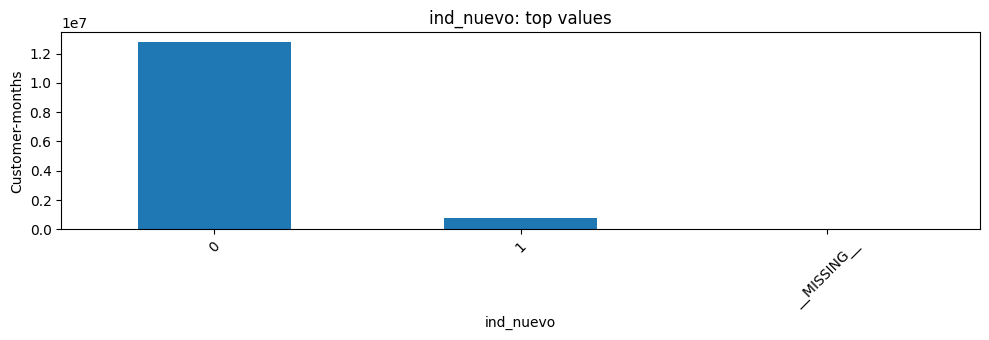

In [327]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ind_nuevo_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ind_nuevo: top values")
ax.set(xlabel="ind_nuevo", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [328]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("ind_nuevo", "categorical", ind_nuevo_values)

**Insight.** Giá trị phổ biến nhất là 0 với **93.853%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [329]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ind_nuevo_associations = deep_association_table("ind_nuevo")
display(ind_nuevo_associations)

,candidate_partner,how_to_combine
0,antiguedad,Validate as an interaction with time-based split.
1,fecha_alta,Validate as an interaction with time-based split.
2,age,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — ind_nuevo

In [330]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ind_nuevo", ind_nuevo_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indrel — Trạng thái khách hàng chính

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [331]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
indrel_overview = deep_overview("indrel")
display(indrel_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [332]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("indrel", indrel_overview)

**Insight.** indrel có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [333]:
# Logic: test whether missingness changes by monthly snapshot.
indrel_missing_by_month = deep_missing_by_month("indrel")
display(indrel_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [334]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
indrel_history_missing = deep_history_missing("indrel")
display(indrel_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [335]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
indrel_missing_by_indrel_1mes = deep_missing_by_driver("indrel", "indrel_1mes")
display(indrel_missing_by_indrel_1mes)

,indrel_1mes,rows,missing_count,missing_pct
0,1.0,9133383,0.0,0.000
1,1,4357298,0.0,0.000
2,__MISSING__,149781,27734.0,18.516
3,3.0,2780,0.0,0.000
4,3,1570,0.0,0.000
5,P,874,0.0,0.000
6,2.0,740,0.0,0.000
7,2,577,0.0,0.000
8,4.0,223,0.0,0.000
9,4,83,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [336]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("indrel", indrel_history_missing, "indrel_1mes")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo indrel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [337]:
# Logic: count the most frequent categorical/date values, including physical missingness.
indrel_values = deep_top_values("indrel")
display(indrel_values)

,value,rows,pct
0,1,13594782,99.615
1,__MISSING__,27734,0.203
2,99,24793,0.182


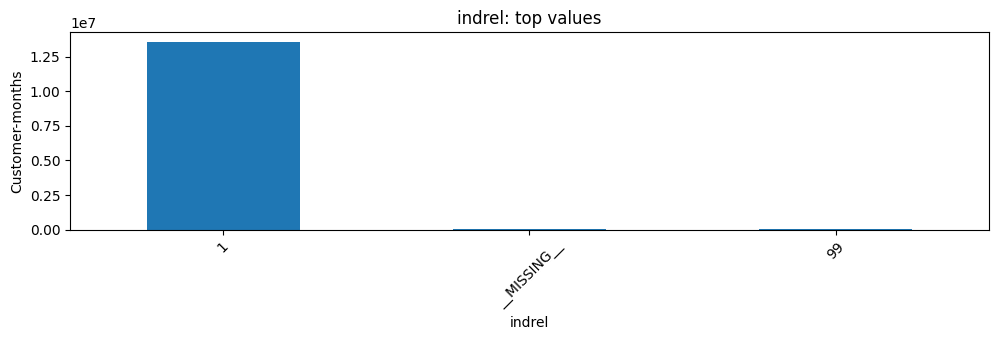

In [338]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = indrel_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="indrel: top values")
ax.set(xlabel="indrel", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [339]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("indrel", "categorical", indrel_values)

**Insight.** Giá trị phổ biến nhất là 1 với **99.615%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [340]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
indrel_associations = deep_association_table("indrel")
display(indrel_associations)

,candidate_partner,how_to_combine
0,indrel_1mes,Validate as an interaction with time-based split.
1,tiprel_1mes,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ult_fec_cli_1t,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — indrel

In [341]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("indrel", indrel_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indrel_1mes — Loại khách hàng đầu tháng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [342]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
indrel_1mes_overview = deep_overview("indrel_1mes")
display(indrel_1mes_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,149781.0,1.098,9


**Insight — completeness & cardinality**

In [343]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("indrel_1mes", indrel_1mes_overview)

**Insight.** indrel_1mes có **149,781** giá trị thiếu (**1.098%**) và **9** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [344]:
# Logic: test whether missingness changes by monthly snapshot.
indrel_1mes_missing_by_month = deep_missing_by_month("indrel_1mes")
display(indrel_1mes_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,16405.0,1.977
7,2015-08-28,843201,11493.0,1.363
8,2015-09-28,865440,22592.0,2.610
9,2015-10-28,892251,26599.0,2.981


In [345]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
indrel_1mes_history_missing = deep_history_missing("indrel_1mes")
display(indrel_1mes_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,149781.0,26.0,0.02


In [346]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
indrel_1mes_missing_by_tiprel_1mes = deep_missing_by_driver("indrel_1mes", "tiprel_1mes")
display(indrel_1mes_missing_by_tiprel_1mes)

,tiprel_1mes,rows,missing_count,missing_pct
0,I,7304875,0.0,0.0
1,A,6187123,0.0,0.0
2,__MISSING__,149781,149781.0,100.0
3,P,4656,0.0,0.0
4,R,870,0.0,0.0
5,N,4,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [347]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("indrel_1mes", indrel_1mes_history_missing, "tiprel_1mes")

**Insight.** Có **149,781** missing; **0.02%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo tiprel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [348]:
# Logic: count the most frequent categorical/date values, including physical missingness.
indrel_1mes_values = deep_top_values("indrel_1mes")
display(indrel_1mes_values)

,value,rows,pct
0,1.0,9133383,66.924
1,1,4357298,31.928
2,__MISSING__,149781,1.098
3,3.0,2780,0.020
4,3,1570,0.012
5,P,874,0.006
6,2.0,740,0.005
7,2,577,0.004
8,4.0,223,0.002
9,4,83,0.001


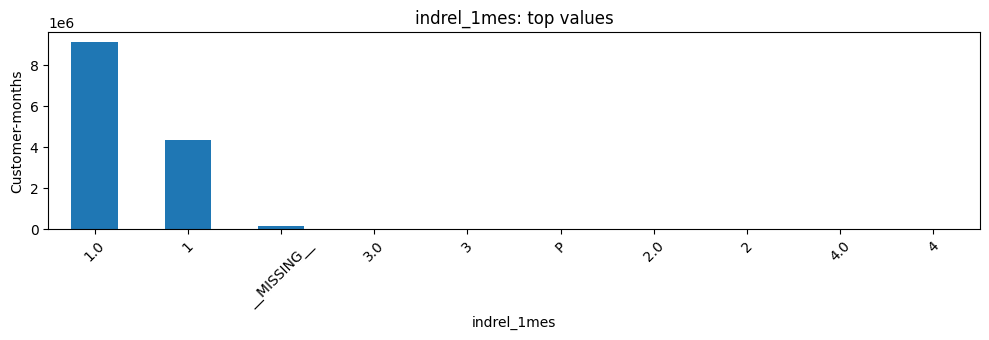

In [349]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = indrel_1mes_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="indrel_1mes: top values")
ax.set(xlabel="indrel_1mes", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [350]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("indrel_1mes", "categorical", indrel_1mes_values)

**Insight.** Giá trị phổ biến nhất là 1.0 với **66.924%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [351]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
indrel_1mes_associations = deep_association_table("indrel_1mes")
display(indrel_1mes_associations)

,candidate_partner,how_to_combine
0,indrel,Validate as an interaction with time-based split.
1,tiprel_1mes,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ind_nuevo,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — indrel_1mes

In [352]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("indrel_1mes", indrel_1mes_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### tiprel_1mes — Loại quan hệ khách hàng đầu tháng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [353]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
tiprel_1mes_overview = deep_overview("tiprel_1mes")
display(tiprel_1mes_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,149781.0,1.098,5


**Insight — completeness & cardinality**

In [354]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("tiprel_1mes", tiprel_1mes_overview)

**Insight.** tiprel_1mes có **149,781** giá trị thiếu (**1.098%**) và **5** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [355]:
# Logic: test whether missingness changes by monthly snapshot.
tiprel_1mes_missing_by_month = deep_missing_by_month("tiprel_1mes")
display(tiprel_1mes_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,16405.0,1.977
7,2015-08-28,843201,11493.0,1.363
8,2015-09-28,865440,22592.0,2.610
9,2015-10-28,892251,26599.0,2.981


In [356]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
tiprel_1mes_history_missing = deep_history_missing("tiprel_1mes")
display(tiprel_1mes_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,149781.0,26.0,0.02


In [357]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
tiprel_1mes_missing_by_indrel_1mes = deep_missing_by_driver("tiprel_1mes", "indrel_1mes")
display(tiprel_1mes_missing_by_indrel_1mes)

,indrel_1mes,rows,missing_count,missing_pct
0,1.0,9133383,0.0,0.0
1,1,4357298,0.0,0.0
2,__MISSING__,149781,149781.0,100.0
3,3.0,2780,0.0,0.0
4,3,1570,0.0,0.0
5,P,874,0.0,0.0
6,2.0,740,0.0,0.0
7,2,577,0.0,0.0
8,4.0,223,0.0,0.0
9,4,83,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [358]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("tiprel_1mes", tiprel_1mes_history_missing, "indrel_1mes")

**Insight.** Có **149,781** missing; **0.02%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo indrel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [359]:
# Logic: count the most frequent categorical/date values, including physical missingness.
tiprel_1mes_values = deep_top_values("tiprel_1mes")
display(tiprel_1mes_values)

,value,rows,pct
0,I,7304875,53.526
1,A,6187123,45.336
2,__MISSING__,149781,1.098
3,P,4656,0.034
4,R,870,0.006
5,N,4,0.000


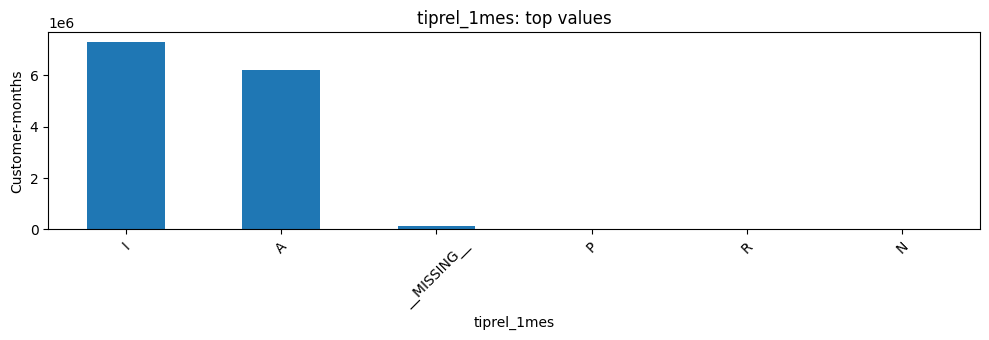

In [360]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = tiprel_1mes_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="tiprel_1mes: top values")
ax.set(xlabel="tiprel_1mes", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [361]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("tiprel_1mes", "categorical", tiprel_1mes_values)

**Insight.** Giá trị phổ biến nhất là I với **53.526%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [362]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
tiprel_1mes_associations = deep_association_table("tiprel_1mes")
display(tiprel_1mes_associations)

,candidate_partner,how_to_combine
0,indrel_1mes,Validate as an interaction with time-based split.
1,indrel,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ult_fec_cli_1t,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — tiprel_1mes

In [363]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("tiprel_1mes", tiprel_1mes_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ind_actividad_cliente — Cờ hoạt động khách hàng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [364]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ind_actividad_cliente_overview = deep_overview("ind_actividad_cliente")
display(ind_actividad_cliente_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [365]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ind_actividad_cliente", ind_actividad_cliente_overview)

**Insight.** ind_actividad_cliente có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [366]:
# Logic: test whether missingness changes by monthly snapshot.
ind_actividad_cliente_missing_by_month = deep_missing_by_month("ind_actividad_cliente")
display(ind_actividad_cliente_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [367]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ind_actividad_cliente_history_missing = deep_history_missing("ind_actividad_cliente")
display(ind_actividad_cliente_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [368]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ind_actividad_cliente_missing_by_tiprel_1mes = deep_missing_by_driver("ind_actividad_cliente", "tiprel_1mes")
display(ind_actividad_cliente_missing_by_tiprel_1mes)

,tiprel_1mes,rows,missing_count,missing_pct
0,I,7304875,0.0,0.000
1,A,6187123,0.0,0.000
2,__MISSING__,149781,27734.0,18.516
3,P,4656,0.0,0.000
4,R,870,0.0,0.000
5,N,4,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [369]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ind_actividad_cliente", ind_actividad_cliente_history_missing, "tiprel_1mes")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo tiprel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [370]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ind_actividad_cliente_values = deep_top_values("ind_actividad_cliente")
display(ind_actividad_cliente_values)

,value,rows,pct
0,0,7384390,54.109
1,1,6235185,45.688
2,__MISSING__,27734,0.203


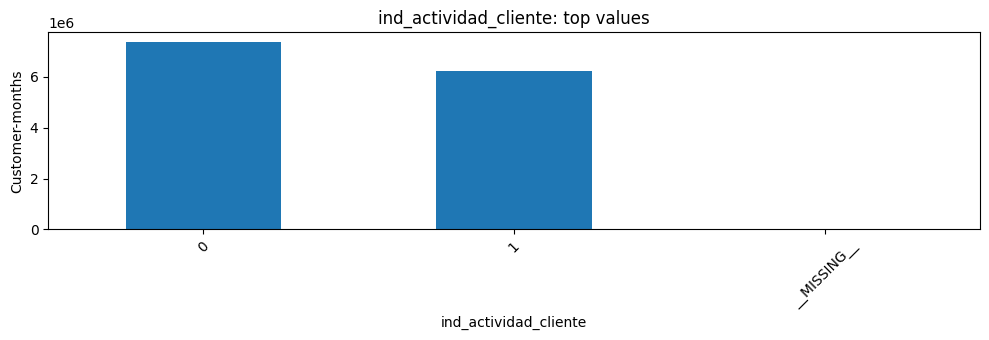

In [371]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ind_actividad_cliente_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ind_actividad_cliente: top values")
ax.set(xlabel="ind_actividad_cliente", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [372]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("ind_actividad_cliente", "categorical", ind_actividad_cliente_values)

**Insight.** Giá trị phổ biến nhất là 0 với **54.109%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [373]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ind_actividad_cliente_associations = deep_association_table("ind_actividad_cliente")
display(ind_actividad_cliente_associations)

,candidate_partner,how_to_combine
0,tiprel_1mes,Validate as an interaction with time-based split.
1,indrel_1mes,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — ind_actividad_cliente

In [374]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ind_actividad_cliente", ind_actividad_cliente_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ind_empleado — Chỉ số nhân viên ngân hàng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [375]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ind_empleado_overview = deep_overview("ind_empleado")
display(ind_empleado_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,5


**Insight — completeness & cardinality**

In [376]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ind_empleado", ind_empleado_overview)

**Insight.** ind_empleado có **27,734** giá trị thiếu (**0.203%**) và **5** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [377]:
# Logic: test whether missingness changes by monthly snapshot.
ind_empleado_missing_by_month = deep_missing_by_month("ind_empleado")
display(ind_empleado_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [378]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ind_empleado_history_missing = deep_history_missing("ind_empleado")
display(ind_empleado_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [379]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ind_empleado_missing_by_conyuemp = deep_missing_by_driver("ind_empleado", "conyuemp")
display(ind_empleado_missing_by_conyuemp)

,conyuemp,rows,missing_count,missing_pct
0,__MISSING__,13645501,27734.0,0.203
1,N,1791,0.0,0.000
2,S,17,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [380]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ind_empleado", ind_empleado_history_missing, "conyuemp")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo conyuemp là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [381]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ind_empleado_values = deep_top_values("ind_empleado")
display(ind_empleado_values)

,value,rows,pct
0,N,13610977,99.734
1,__MISSING__,27734,0.203
2,B,3566,0.026
3,F,2523,0.018
4,A,2492,0.018
5,S,17,0.000


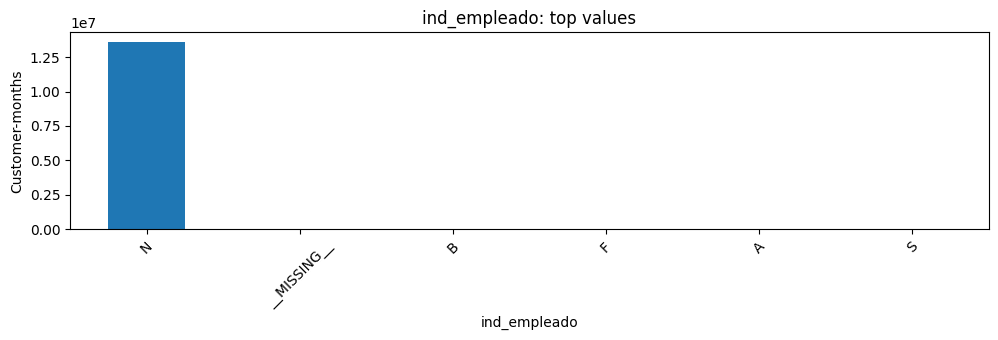

In [382]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ind_empleado_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ind_empleado: top values")
ax.set(xlabel="ind_empleado", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [383]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("ind_empleado", "categorical", ind_empleado_values)

**Insight.** Giá trị phổ biến nhất là N với **99.734%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [384]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ind_empleado_associations = deep_association_table("ind_empleado")
display(ind_empleado_associations)

,candidate_partner,how_to_combine
0,conyuemp,Validate as an interaction with time-based split.
1,canal_entrada,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,renta,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — ind_empleado

In [385]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ind_empleado", ind_empleado_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indfall — Cờ đã qua đời

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [386]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
indfall_overview = deep_overview("indfall")
display(indfall_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [387]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("indfall", indfall_overview)

**Insight.** indfall có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [388]:
# Logic: test whether missingness changes by monthly snapshot.
indfall_missing_by_month = deep_missing_by_month("indfall")
display(indfall_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [389]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
indfall_history_missing = deep_history_missing("indfall")
display(indfall_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [390]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
indfall_missing_by_ind_actividad_cliente = deep_missing_by_driver("indfall", "ind_actividad_cliente")
display(indfall_missing_by_ind_actividad_cliente)

,ind_actividad_cliente,rows,missing_count,missing_pct
0,0,7384390,0.0,0.0
1,1,6235185,0.0,0.0
2,__MISSING__,27734,27734.0,100.0


**Insight — missingness hypothesis and treatment**

In [391]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("indfall", indfall_history_missing, "ind_actividad_cliente")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_actividad_cliente là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [392]:
# Logic: count the most frequent categorical/date values, including physical missingness.
indfall_values = deep_top_values("indfall")
display(indfall_values)

,value,rows,pct
0,N,13584813,99.542
1,S,34762,0.255
2,__MISSING__,27734,0.203


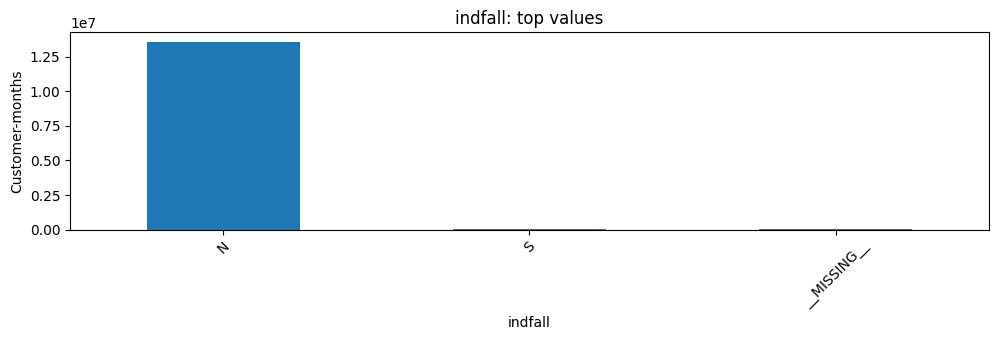

In [393]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = indfall_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="indfall: top values")
ax.set(xlabel="indfall", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [394]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("indfall", "categorical", indfall_values)

**Insight.** Giá trị phổ biến nhất là N với **99.542%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [395]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
indfall_associations = deep_association_table("indfall")
display(indfall_associations)

,candidate_partner,how_to_combine
0,ind_actividad_cliente,Validate as an interaction with time-based split.
1,tiprel_1mes,Validate as an interaction with time-based split.
2,indrel_1mes,Validate as an interaction with time-based split.
3,ult_fec_cli_1t,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — indfall

In [396]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("indfall", indfall_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### sexo — Giới tính

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [397]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
sexo_overview = deep_overview("sexo")
display(sexo_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27804.0,0.204,2


**Insight — completeness & cardinality**

In [398]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("sexo", sexo_overview)

**Insight.** sexo có **27,804** giá trị thiếu (**0.204%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [399]:
# Logic: test whether missingness changes by monthly snapshot.
sexo_missing_by_month = deep_missing_by_month("sexo")
display(sexo_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6955.0,1.112
1,2015-02-28,627394,5942.0,0.947
2,2015-03-28,629209,5094.0,0.810
3,2015-04-28,630367,4295.0,0.681
4,2015-05-28,631957,3600.0,0.570
5,2015-06-28,632110,1864.0,0.295
6,2015-07-28,829817,4.0,0.000
7,2015-08-28,843201,5.0,0.001
8,2015-09-28,865440,5.0,0.001
9,2015-10-28,892251,5.0,0.001


In [400]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
sexo_history_missing = deep_history_missing("sexo")
display(sexo_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27804.0,0.0,0.0


In [401]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
sexo_missing_by_segmento = deep_missing_by_driver("sexo", "segmento")
display(sexo_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,69.0,0.001
1,03 - UNIVERSITARIO,4935579,0.0,0.000
2,01 - TOP,562142,0.0,0.000
3,__MISSING__,189368,27735.0,14.646


**Insight — missingness hypothesis and treatment**

In [402]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("sexo", sexo_history_missing, "segmento")

**Insight.** Có **27,804** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [403]:
# Logic: count the most frequent categorical/date values, including physical missingness.
sexo_values = deep_top_values("sexo")
display(sexo_values)

,value,rows,pct
0,V,7424252,54.401
1,H,6195253,45.395
2,__MISSING__,27804,0.204


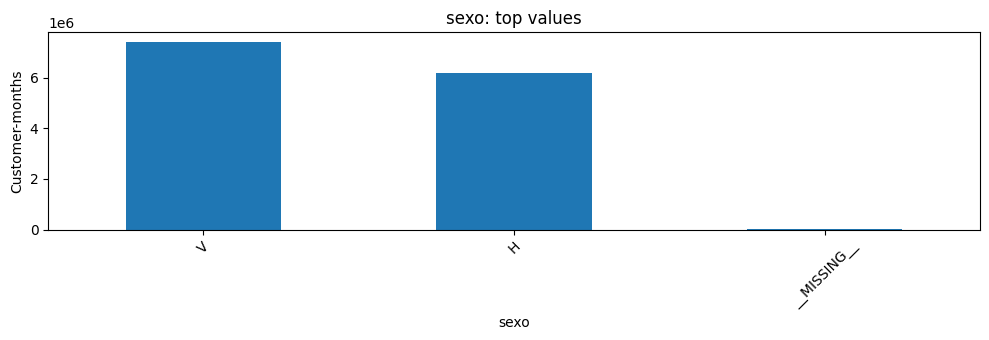

In [404]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = sexo_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="sexo: top values")
ax.set(xlabel="sexo", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [405]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("sexo", "categorical", sexo_values)

**Insight.** Giá trị phổ biến nhất là V với **54.401%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [406]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
sexo_associations = deep_association_table("sexo")
display(sexo_associations)

,candidate_partner,how_to_combine
0,age,Validate as an interaction with time-based split.
1,renta,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — sexo

In [407]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("sexo", sexo_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### pais_residencia — Quốc gia cư trú

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [408]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
pais_residencia_overview = deep_overview("pais_residencia")
display(pais_residencia_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,118


**Insight — completeness & cardinality**

In [409]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("pais_residencia", pais_residencia_overview)

**Insight.** pais_residencia có **27,734** giá trị thiếu (**0.203%**) và **118** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [410]:
# Logic: test whether missingness changes by monthly snapshot.
pais_residencia_missing_by_month = deep_missing_by_month("pais_residencia")
display(pais_residencia_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [411]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
pais_residencia_history_missing = deep_history_missing("pais_residencia")
display(pais_residencia_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [412]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
pais_residencia_missing_by_canal_entrada = deep_missing_by_driver("pais_residencia", "canal_entrada")
display(pais_residencia_missing_by_canal_entrada)

,canal_entrada,rows,missing_count,missing_pct
0,KHE,4055270,0.0,0.000
1,KAT,3268209,0.0,0.000
2,KFC,3098360,0.0,0.000
3,KHQ,591039,0.0,0.000
4,KFA,409669,0.0,0.000
5,KHK,241084,0.0,0.000
6,__MISSING__,186126,27734.0,14.901
7,KHM,183924,0.0,0.000
8,KHD,116891,0.0,0.000
9,KHN,116608,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [413]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("pais_residencia", pais_residencia_history_missing, "canal_entrada")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo canal_entrada là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [414]:
# Logic: count the most frequent categorical/date values, including physical missingness.
pais_residencia_values = deep_top_values("pais_residencia")
display(pais_residencia_values)

,value,rows,pct
0,ES,13553710,99.314
1,__MISSING__,27734,0.203
2,FR,5161,0.038
3,AR,4835,0.035
4,DE,4625,0.034
5,GB,4605,0.034
6,US,3651,0.027
7,CO,3526,0.026
8,IT,2947,0.022
9,RO,2931,0.021


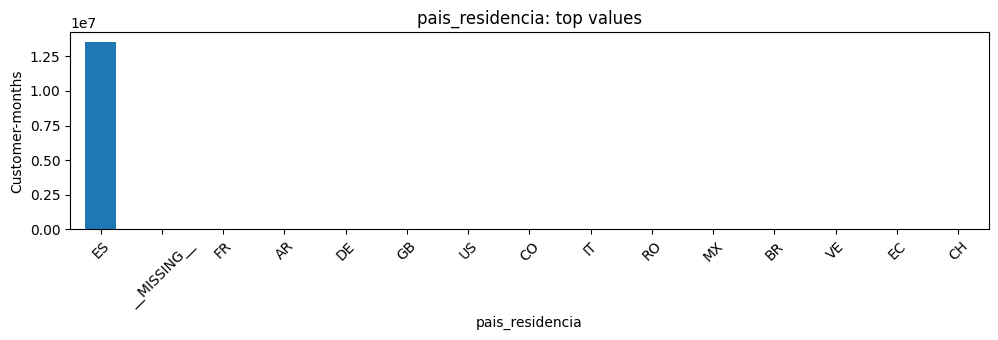

In [415]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = pais_residencia_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="pais_residencia: top values")
ax.set(xlabel="pais_residencia", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [416]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("pais_residencia", "categorical", pais_residencia_values)

**Insight.** Giá trị phổ biến nhất là ES với **99.314%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [417]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
pais_residencia_associations = deep_association_table("pais_residencia")
display(pais_residencia_associations)

,candidate_partner,how_to_combine
0,cod_prov,Validate as an interaction with time-based split.
1,nomprov,Validate as an interaction with time-based split.
2,canal_entrada,Validate as an interaction with time-based split.
3,segmento,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — pais_residencia

In [418]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("pais_residencia", pais_residencia_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### cod_prov — Mã tỉnh/thành phố

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [419]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
cod_prov_overview = deep_overview("cod_prov")
display(cod_prov_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,93591.0,0.686,52


**Insight — completeness & cardinality**

In [420]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("cod_prov", cod_prov_overview)

**Insight.** cod_prov có **93,591** giá trị thiếu (**0.686%**) và **52** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [421]:
# Logic: test whether missingness changes by monthly snapshot.
cod_prov_missing_by_month = deep_missing_by_month("cod_prov")
display(cod_prov_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,10631.0,1.700
1,2015-02-28,627394,9617.0,1.533
2,2015-03-28,629209,8769.0,1.394
3,2015-04-28,630367,7969.0,1.264
4,2015-05-28,631957,7275.0,1.151
5,2015-06-28,632110,5536.0,0.876
6,2015-07-28,829817,3975.0,0.479
7,2015-08-28,843201,3977.0,0.472
8,2015-09-28,865440,3976.0,0.459
9,2015-10-28,892251,3976.0,0.446


In [422]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
cod_prov_history_missing = deep_history_missing("cod_prov")
display(cod_prov_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,93591.0,300.0,0.32


In [423]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
cod_prov_missing_by_nomprov = deep_missing_by_driver("cod_prov", "nomprov")
display(cod_prov_missing_by_nomprov)

,nomprov,rows,missing_count,missing_pct
0,MADRID,4409600,0.0,0.0
1,BARCELONA,1275219,0.0,0.0
2,VALENCIA,682304,0.0,0.0
3,SEVILLA,605164,0.0,0.0
4,"CORUÑA, A",429322,0.0,0.0
5,MURCIA,396759,0.0,0.0
6,MALAGA,367023,0.0,0.0
7,ZARAGOZA,342543,0.0,0.0
8,ALICANTE,313397,0.0,0.0
9,CADIZ,294684,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [424]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("cod_prov", cod_prov_history_missing, "nomprov")

**Insight.** Có **93,591** missing; **0.32%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo nomprov là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [425]:
# Logic: count the most frequent categorical/date values, including physical missingness.
cod_prov_values = deep_top_values("cod_prov")
display(cod_prov_values)

,value,rows,pct
0,28,4409600,32.311
1,8,1275219,9.344
2,46,682304,5.000
3,41,605164,4.434
4,15,429322,3.146
5,30,396759,2.907
6,29,367023,2.689
7,50,342543,2.510
8,3,313397,2.296
9,11,294684,2.159


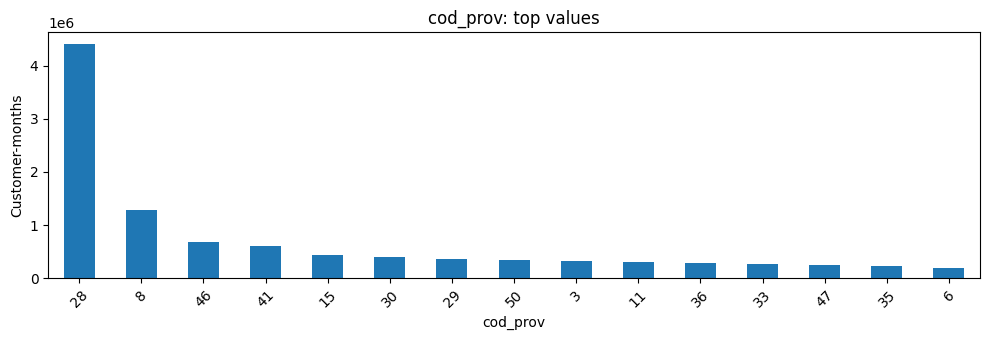

In [426]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = cod_prov_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="cod_prov: top values")
ax.set(xlabel="cod_prov", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [427]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("cod_prov", "categorical", cod_prov_values)

**Insight.** Giá trị phổ biến nhất là 28 với **32.311%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [428]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
cod_prov_associations = deep_association_table("cod_prov")
display(cod_prov_associations)

,candidate_partner,how_to_combine
0,nomprov,Validate as an interaction with time-based split.
1,renta,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — cod_prov

In [429]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("cod_prov", cod_prov_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### nomprov — Tên tỉnh/thành phố

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [430]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
nomprov_overview = deep_overview("nomprov")
display(nomprov_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,93591.0,0.686,52


**Insight — completeness & cardinality**

In [431]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("nomprov", nomprov_overview)

**Insight.** nomprov có **93,591** giá trị thiếu (**0.686%**) và **52** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [432]:
# Logic: test whether missingness changes by monthly snapshot.
nomprov_missing_by_month = deep_missing_by_month("nomprov")
display(nomprov_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,10631.0,1.700
1,2015-02-28,627394,9617.0,1.533
2,2015-03-28,629209,8769.0,1.394
3,2015-04-28,630367,7969.0,1.264
4,2015-05-28,631957,7275.0,1.151
5,2015-06-28,632110,5536.0,0.876
6,2015-07-28,829817,3975.0,0.479
7,2015-08-28,843201,3977.0,0.472
8,2015-09-28,865440,3976.0,0.459
9,2015-10-28,892251,3976.0,0.446


In [433]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
nomprov_history_missing = deep_history_missing("nomprov")
display(nomprov_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,93591.0,300.0,0.32


In [434]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
nomprov_missing_by_cod_prov = deep_missing_by_driver("nomprov", "cod_prov")
display(nomprov_missing_by_cod_prov)

,cod_prov,rows,missing_count,missing_pct
0,28,4409600,0.0,0.0
1,8,1275219,0.0,0.0
2,46,682304,0.0,0.0
3,41,605164,0.0,0.0
4,15,429322,0.0,0.0
5,30,396759,0.0,0.0
6,29,367023,0.0,0.0
7,50,342543,0.0,0.0
8,3,313397,0.0,0.0
9,11,294684,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [435]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("nomprov", nomprov_history_missing, "cod_prov")

**Insight.** Có **93,591** missing; **0.32%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo cod_prov là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [436]:
# Logic: count the most frequent categorical/date values, including physical missingness.
nomprov_values = deep_top_values("nomprov")
display(nomprov_values)

,value,rows,pct
0,MADRID,4409600,32.311
1,BARCELONA,1275219,9.344
2,VALENCIA,682304,5.000
3,SEVILLA,605164,4.434
4,"CORUÑA, A",429322,3.146
5,MURCIA,396759,2.907
6,MALAGA,367023,2.689
7,ZARAGOZA,342543,2.510
8,ALICANTE,313397,2.296
9,CADIZ,294684,2.159


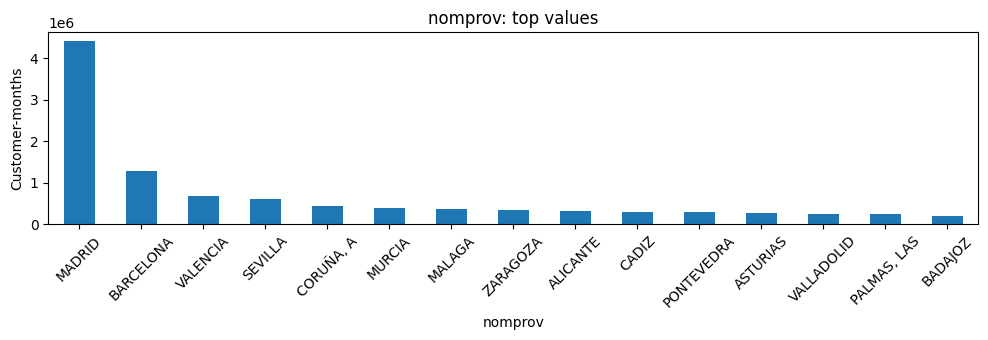

In [437]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = nomprov_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="nomprov: top values")
ax.set(xlabel="nomprov", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [438]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("nomprov", "categorical", nomprov_values)

**Insight.** Giá trị phổ biến nhất là MADRID với **32.311%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [439]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
nomprov_associations = deep_association_table("nomprov")
display(nomprov_associations)

,candidate_partner,how_to_combine
0,cod_prov,Validate as an interaction with time-based split.
1,renta,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — nomprov

In [440]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("nomprov", nomprov_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### canal_entrada — Kênh gia nhập

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [441]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
canal_entrada_overview = deep_overview("canal_entrada")
display(canal_entrada_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,186126.0,1.364,162


**Insight — completeness & cardinality**

In [442]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("canal_entrada", canal_entrada_overview)

**Insight.** canal_entrada có **186,126** giá trị thiếu (**1.364%**) và **162** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [443]:
# Logic: test whether missingness changes by monthly snapshot.
canal_entrada_missing_by_month = deep_missing_by_month("canal_entrada")
display(canal_entrada_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,7004.0,1.120
1,2015-02-28,627394,5982.0,0.953
2,2015-03-28,629209,5130.0,0.815
3,2015-04-28,630367,4327.0,0.686
4,2015-05-28,631957,3626.0,0.574
5,2015-06-28,632110,1882.0,0.298
6,2015-07-28,829817,19077.0,2.299
7,2015-08-28,843201,16705.0,1.981
8,2015-09-28,865440,25542.0,2.951
9,2015-10-28,892251,30475.0,3.416


In [444]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
canal_entrada_history_missing = deep_history_missing("canal_entrada")
display(canal_entrada_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,186126.0,796.0,0.43


In [445]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
canal_entrada_missing_by_segmento = deep_missing_by_driver("canal_entrada", "segmento")
display(canal_entrada_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,691.0,0.009
1,03 - UNIVERSITARIO,4935579,140.0,0.003
2,01 - TOP,562142,16.0,0.003
3,__MISSING__,189368,185279.0,97.841


**Insight — missingness hypothesis and treatment**

In [446]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("canal_entrada", canal_entrada_history_missing, "segmento")

**Insight.** Có **186,126** missing; **0.43%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [447]:
# Logic: count the most frequent categorical/date values, including physical missingness.
canal_entrada_values = deep_top_values("canal_entrada")
display(canal_entrada_values)

,value,rows,pct
0,KHE,4055270,29.715
1,KAT,3268209,23.948
2,KFC,3098360,22.703
3,KHQ,591039,4.331
4,KFA,409669,3.002
5,KHK,241084,1.767
6,__MISSING__,186126,1.364
7,KHM,183924,1.348
8,KHD,116891,0.857
9,KHN,116608,0.854


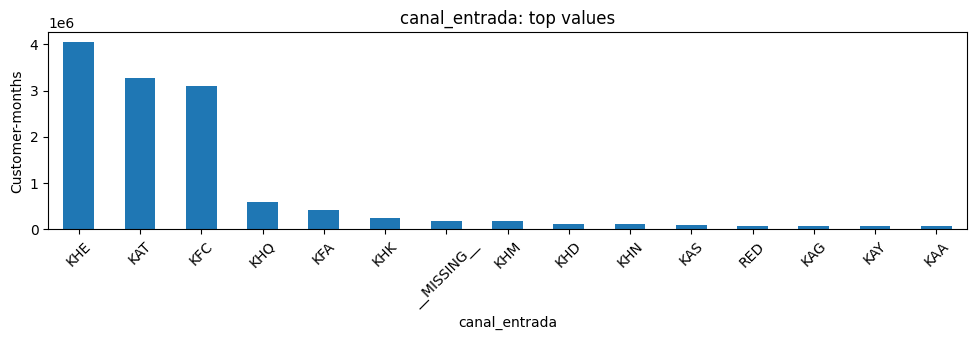

In [448]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = canal_entrada_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="canal_entrada: top values")
ax.set(xlabel="canal_entrada", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [449]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("canal_entrada", "categorical", canal_entrada_values)

**Insight.** Giá trị phổ biến nhất là KHE với **29.715%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [450]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
canal_entrada_associations = deep_association_table("canal_entrada")
display(canal_entrada_associations)

,candidate_partner,how_to_combine
0,segmento,Validate as an interaction with time-based split.
1,ind_nuevo,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ind_empleado,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — canal_entrada

In [451]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("canal_entrada", canal_entrada_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### segmento — Phân đoạn khách hàng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [452]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
segmento_overview = deep_overview("segmento")
display(segmento_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,189368.0,1.388,3


**Insight — completeness & cardinality**

In [453]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("segmento", segmento_overview)

**Insight.** segmento có **189,368** giá trị thiếu (**1.388%**) và **3** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [454]:
# Logic: test whether missingness changes by monthly snapshot.
segmento_missing_by_month = deep_missing_by_month("segmento")
display(segmento_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,7024.0,1.123
1,2015-02-28,627394,6003.0,0.957
2,2015-03-28,629209,5145.0,0.818
3,2015-04-28,630367,4321.0,0.685
4,2015-05-28,631957,3619.0,0.573
5,2015-06-28,632110,1868.0,0.296
6,2015-07-28,829817,19358.0,2.333
7,2015-08-28,843201,16981.0,2.014
8,2015-09-28,865440,25848.0,2.987
9,2015-10-28,892251,30726.0,3.444


In [455]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
segmento_history_missing = deep_history_missing("segmento")
display(segmento_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,189368.0,815.0,0.43


In [456]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
segmento_missing_by_canal_entrada = deep_missing_by_driver("segmento", "canal_entrada")
display(segmento_missing_by_canal_entrada)

,canal_entrada,rows,missing_count,missing_pct
0,KHE,4055270,8.0,0.000
1,KAT,3268209,1825.0,0.056
2,KFC,3098360,869.0,0.028
3,KHQ,591039,2.0,0.000
4,KFA,409669,194.0,0.047
5,KHK,241084,70.0,0.029
6,__MISSING__,186126,185279.0,99.545
7,KHM,183924,172.0,0.094
8,KHD,116891,0.0,0.000
9,KHN,116608,160.0,0.137


**Insight — missingness hypothesis and treatment**

In [457]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("segmento", segmento_history_missing, "canal_entrada")

**Insight.** Có **189,368** missing; **0.43%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo canal_entrada là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [458]:
# Logic: count the most frequent categorical/date values, including physical missingness.
segmento_values = deep_top_values("segmento")
display(segmento_values)

,value,rows,pct
0,02 - PARTICULARES,7960220,58.328
1,03 - UNIVERSITARIO,4935579,36.165
2,01 - TOP,562142,4.119
3,__MISSING__,189368,1.388


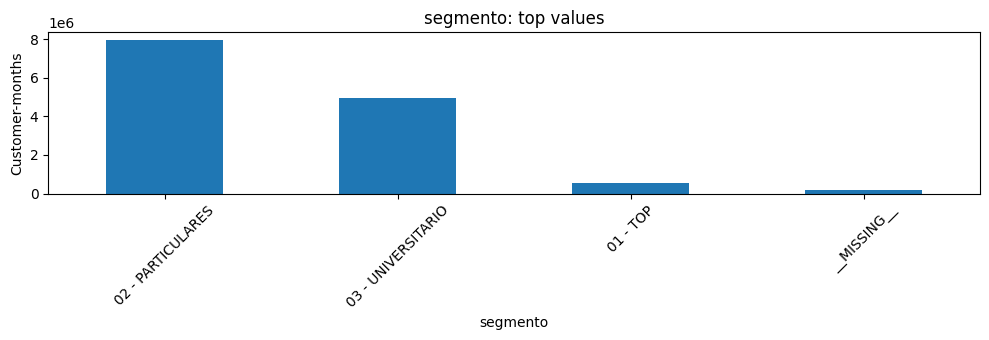

In [459]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = segmento_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="segmento: top values")
ax.set(xlabel="segmento", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [460]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("segmento", "categorical", segmento_values)

**Insight.** Giá trị phổ biến nhất là 02 - PARTICULARES với **58.328%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [461]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
segmento_associations = deep_association_table("segmento")
display(segmento_associations)

,candidate_partner,how_to_combine
0,renta,Validate as an interaction with time-based split.
1,age,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — segmento

In [462]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("segmento", segmento_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### fecha_alta — Ngày gia nhập ngân hàng

Biến thời gian; kiểm tra missingness, tần suất ngày và các derived features theo snapshot.

In [463]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
fecha_alta_overview = deep_overview("fecha_alta")
display(fecha_alta_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,6756


**Insight — completeness & cardinality**

In [464]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("fecha_alta", fecha_alta_overview)

**Insight.** fecha_alta có **27,734** giá trị thiếu (**0.203%**) và **6,756** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [465]:
# Logic: test whether missingness changes by monthly snapshot.
fecha_alta_missing_by_month = deep_missing_by_month("fecha_alta")
display(fecha_alta_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [466]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
fecha_alta_history_missing = deep_history_missing("fecha_alta")
display(fecha_alta_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [467]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
fecha_alta_missing_by_ind_nuevo = deep_missing_by_driver("fecha_alta", "ind_nuevo")
display(fecha_alta_missing_by_ind_nuevo)

,ind_nuevo,rows,missing_count,missing_pct
0,0,12808368,0.0,0.0
1,1,811207,0.0,0.0
2,__MISSING__,27734,27734.0,100.0


**Insight — missingness hypothesis and treatment**

In [468]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("fecha_alta", fecha_alta_history_missing, "ind_nuevo")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_nuevo là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [469]:
# Logic: count the most frequent categorical/date values, including physical missingness.
fecha_alta_values = deep_top_values("fecha_alta")
display(fecha_alta_values)

,value,rows,pct
0,2014-07-28 00:00:00,57389,0.421
1,2014-10-03 00:00:00,54287,0.398
2,2014-08-04 00:00:00,45746,0.335
3,2013-10-14 00:00:00,40804,0.299
4,2013-08-03 00:00:00,33414,0.245
5,__MISSING__,27734,0.203
6,2012-08-06 00:00:00,26223,0.192
7,2014-07-21 00:00:00,26027,0.191
8,2012-08-03 00:00:00,25409,0.186
9,2012-08-02 00:00:00,25004,0.183


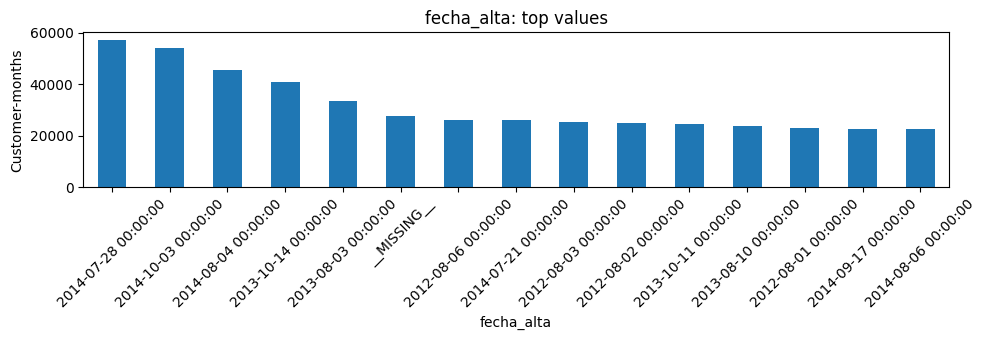

In [470]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = fecha_alta_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="fecha_alta: top values")
ax.set(xlabel="fecha_alta", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and time-feature transformation**

In [487]:
# Logic: state the date-feature transformation decision; raw dates are not encoded directly.
from IPython.display import Markdown, display
display(Markdown("**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng."))

**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng.

In [472]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
fecha_alta_associations = deep_association_table("fecha_alta")
display(fecha_alta_associations)

,candidate_partner,how_to_combine
0,antiguedad,Validate as an interaction with time-based split.
1,ind_nuevo,Validate as an interaction with time-based split.
2,age,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — fecha_alta

In [473]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("fecha_alta", fecha_alta_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ult_fec_cli_1t — Ngày cuối là khách hàng chính

Biến thời gian; kiểm tra missingness, tần suất ngày và các derived features theo snapshot.

In [474]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ult_fec_cli_1t_overview = deep_overview("ult_fec_cli_1t")
display(ult_fec_cli_1t_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,13622516.0,99.818,223


**Insight — completeness & cardinality**

In [475]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ult_fec_cli_1t", ult_fec_cli_1t_overview)

**Insight.** ult_fec_cli_1t có **13,622,516** giá trị thiếu (**99.818%**) và **223** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [476]:
# Logic: test whether missingness changes by monthly snapshot.
ult_fec_cli_1t_missing_by_month = deep_missing_by_month("ult_fec_cli_1t")
display(ult_fec_cli_1t_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,624694.0,99.878
1,2015-02-28,627394,626601.0,99.874
2,2015-03-28,629209,628402.0,99.872
3,2015-04-28,630367,629576.0,99.875
4,2015-05-28,631957,631172.0,99.876
5,2015-06-28,632110,631328.0,99.876
6,2015-07-28,829817,828392.0,99.828
7,2015-08-28,843201,841859.0,99.841
8,2015-09-28,865440,863707.0,99.800
9,2015-10-28,892251,890239.0,99.775


In [477]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ult_fec_cli_1t_history_missing = deep_history_missing("ult_fec_cli_1t")
display(ult_fec_cli_1t_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,13622516.0,2555.0,0.02


In [478]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ult_fec_cli_1t_missing_by_indrel_1mes = deep_missing_by_driver("ult_fec_cli_1t", "indrel_1mes")
display(ult_fec_cli_1t_missing_by_indrel_1mes)

,indrel_1mes,rows,missing_count,missing_pct
0,1.0,9133383,9121693.0,99.872
1,1,4357298,4348682.0,99.802
2,__MISSING__,149781,145869.0,97.388
3,3.0,2780,2494.0,89.712
4,3,1570,1339.0,85.287
5,P,874,846.0,96.796
6,2.0,740,734.0,99.189
7,2,577,567.0,98.267
8,4.0,223,209.0,93.722
9,4,83,83.0,100.000


**Insight — missingness hypothesis and treatment**

In [479]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ult_fec_cli_1t", ult_fec_cli_1t_history_missing, "indrel_1mes")

**Insight.** Có **13,622,516** missing; **0.02%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo indrel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [480]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ult_fec_cli_1t_values = deep_top_values("ult_fec_cli_1t")
display(ult_fec_cli_1t_values)

,value,rows,pct
0,__MISSING__,13622516,99.818
1,2015-12-24 00:00:00,763,0.006
2,2015-12-28 00:00:00,521,0.004
3,2015-07-09 00:00:00,443,0.003
4,2015-07-06 00:00:00,405,0.003
5,2015-07-01 00:00:00,401,0.003
6,2015-07-21 00:00:00,391,0.003
7,2015-07-07 00:00:00,340,0.002
8,2015-07-17 00:00:00,330,0.002
9,2015-07-10 00:00:00,320,0.002


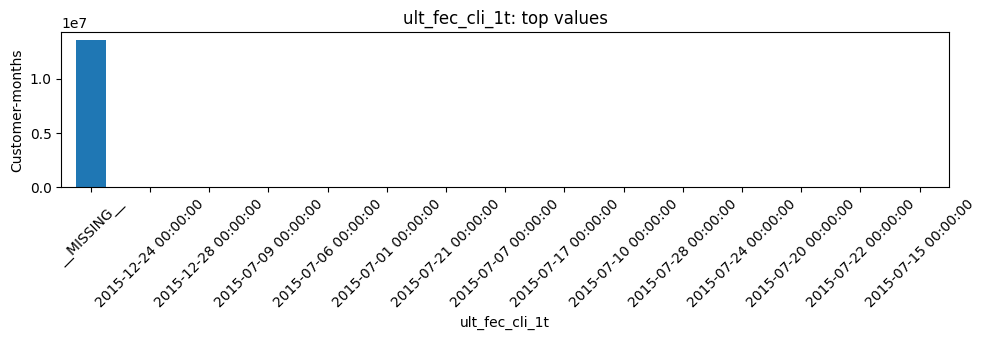

In [481]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ult_fec_cli_1t_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ult_fec_cli_1t: top values")
ax.set(xlabel="ult_fec_cli_1t", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and time-feature transformation**

In [482]:
# Logic: state the date-feature transformation decision; raw dates are not encoded directly.
from IPython.display import Markdown, display
display(Markdown("**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng."))

**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng.

In [483]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ult_fec_cli_1t_associations = deep_association_table("ult_fec_cli_1t")
display(ult_fec_cli_1t_associations)

,candidate_partner,how_to_combine
0,indrel,Validate as an interaction with time-based split.
1,indrel_1mes,Validate as an interaction with time-based split.
2,tiprel_1mes,Validate as an interaction with time-based split.
3,indfall,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — ult_fec_cli_1t

In [484]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ult_fec_cli_1t", ult_fec_cli_1t_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.